# GNN — NinaPro DB7: Strict Leakage-Safe EMG + ACC Subject-Specific Within-Subject Evaluation
## All 22 subjects | Exercise B / E1 only | labels 1–17 | one independent GNN per subject

This notebook uses a **12-electrode EMG graph plus a separate ACC branch**. For every subject and gesture, all six complete repetitions are assigned first (4 train, 1 validation, 1 test). EMG filtering and ACC interval mapping/resampling then occur independently **inside the already-assigned repetition**, before windowing and feature extraction. Scaling and graph construction use training data only during model selection; the final refit uses train+validation only; test remains untouched.


## Cell 1 — Imports

In [1]:
import os, gc, time, json, warnings, random, re
from pathlib import Path
import numpy as np
import pandas as pd

from scipy import io
from scipy.signal import (
    resample_poly, butter, sosfiltfilt, iirnotch, filtfilt
)
from scipy.stats import skew, kurtosis
from math import gcd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve,
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print('Imports done.')


Imports done.


## Cell 2 — Configuration

In [2]:
def _find_kaggle_input() -> Path:
    base = Path('/kaggle/input')
    if not base.exists():
        return Path('/kaggle/input/ninapro-db7/Dataset')

    def _has_subjects(p):
        return p.is_dir() and any(
            c.is_dir() and c.name.lower().startswith('subject_')
            for c in p.iterdir()
        )

    def _search(root, depth=0):
        if depth > 5:
            return None
        if _has_subjects(root):
            return root
        try:
            for child in sorted(root.iterdir()):
                if child.is_dir():
                    result = _search(child, depth + 1)
                    if result is not None:
                        return result
        except PermissionError:
            pass
        return None

    result = _search(base)
    return result if result else Path('/kaggle/input/ninapro-db7/Dataset')


class Config:
    # Paths
    KAGGLE_INPUT   = _find_kaggle_input()
    KAGGLE_WORKING = (
        Path('/kaggle/working')
        if Path('/kaggle').exists()
        else Path.cwd() / 'gnn_within_emg_acc_working'
    )
    RUN_TAG = 'v12_gnn_subject_specific_E1_exerciseB_labels1_17_emg_acc'
    CKPT_DIR = KAGGLE_WORKING / f'ckpts_{RUN_TAG}'
    # Fresh RAW per-file cache: no filtering or ACC resampling is performed before the split.
    DATA_CACHE_DIR = KAGGLE_WORKING / f'raw_file_cache_{RUN_TAG}'
    FEATURE_CACHE_DIR = KAGGLE_WORKING / f'feature_cache_{RUN_TAG}'
    PLOT_DIR = KAGGLE_WORKING / f'plots_{RUN_TAG}'
    RESULTS_DIR = KAGGLE_WORKING / f'results_{RUN_TAG}'

    # Population
    INTACT_SUBJECTS  = list(range(1, 21))
    AMPUTEE_SUBJECTS = [21, 22]
    SUBJECTS = list(range(1, 23))
    # Run all subjects by default. For a quick Kaggle smoke test, use e.g. [1, 2].
    RUN_SUBJECTS = SUBJECTS.copy()
    PLOT_EACH_SUBJECT = False

    # Within-subject repetition protocol: DB7 has six repetitions/gesture.
    REPS_PER_GESTURE = 6
    TRAIN_REPS = 4
    VAL_REPS = 1
    TEST_REPS = 1

    # DB7 Exercise B only. E1 uses local gesture labels 1..17.
    EXERCISE_NAME = 'exerciseB_E1_labels1_17'
    EXERCISE_IDS = (1,)
    GESTURE_MIN = 1
    GESTURE_MAX = 17
    N_CLASSES = GESTURE_MAX - GESTURE_MIN + 1

    # Dataset
    EMG_FS = 2000
    ACC_FS = 148
    TARGET_FS = 2000
    EMG_KEY = 'emg'
    ACC_KEY = 'acc'
    LBL_KEY = 'restimulus'
    N_EMG_CH = 12

    # Strict multimodal experiment: 12-node EMG graph + separate ACC branch.
    USE_ACC = True

    # Signal preprocessing
    BANDPASS_LOW_HZ  = 20.0
    BANDPASS_HIGH_HZ = 450.0
    FILTER_ORDER = 4
    NOTCH_HZ = 50.0
    NOTCH_Q = 30.0

    # Windowing retained from the GNN pipeline.
    WIN_MS = 400
    STEP_MS = 100
    TRIM_MS = 100
    WIN_SAMPLES = int(WIN_MS * TARGET_FS / 1000)
    STEP_SAMPLES = int(STEP_MS * TARGET_FS / 1000)
    TRIM_SAMPLES = int(TRIM_MS * TARGET_FS / 1000)

    # Subject-specific within-subject baseline: retain amplitude information.
    # RobustScaler is fitted separately for every subject on training repetitions only.
    NORMALIZE_EMG_WINDOW = False
    EMG_NORM_CLIP = 12.0

    # EMG features
    MAVSLP_SEGMENTS = 3
    AR_ORDER = 4
    USE_FREQ_FEATURES = False
    THRESHOLD_STD_FACTOR = 0.01
    WAMP_STD_FACTOR = 0.05
    FEATURE_CHUNK_SIZE = 2048

    # ACC-specific features, only if USE_ACC=True.
    ACC_FEATURE_NAMES = (
        'mean', 'std', 'rms', 'range',
        'mean_abs_diff', 'skew', 'kurtosis'
    )

    # Disabled by default for within-subject learning: electrode placement is stable
    # within the same subject, so LOSO-style shift/gain augmentation can be harmful.
    AUGMENT_TRAIN = False
    N_AUG_COPIES = 1
    AUGMENT_GAIN_STD = 0.15
    AUGMENT_NOISE_STD = 0.02
    AUGMENT_MAX_SHIFT = 1

    # GNN
    GRAPH_TOP_K = 3
    GNN_HIDDEN = 64
    GNN_LAYERS = 3
    GRAPH_EMBED_DIM = 128
    ACC_HIDDEN = [64, 32]
    FUSION_HIDDEN = 128
    DROPOUT = 0.15

    # Subject-adversarial training is useful mainly for unseen-subject LOSO.
    # It is disabled by default here because train/test contain the same subjects.
    # The code remains available for an ablation.
    USE_DOMAIN_ADVERSARIAL = False
    DOMAIN_ADV_LAMBDA = 0.10
    DOMAIN_LOSS_WEIGHT = 0.05
    N_DOMAINS = 22

    # Optimization
    MIN_EPOCHS = 20
    MAX_EPOCHS = 150
    PATIENCE = 15
    MIN_REFIT_EPOCHS = 10
    BATCH_SIZE = 128
    LR = 3e-4
    DECAY = 1e-4
    LABEL_SMOOTHING = 0.0
    GRAD_CLIP = 5.0
    NUM_WORKERS = 2

    # Valid within-subject final refit: use train+validation repetitions only.
    REFIT_ON_TRAIN_PLUS_VAL = True

    # Continuous cache version matches the improved 400 ms preprocessing.
    CACHE_VERSION = 'v11_raw_per_file_rep_local_emg_acc'
    WITHIN_FEATURE_CACHE_VERSION = 'v11_subject_specific_emg_acc_rep_local'

    # Reproducibility
    SEED = 42
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if Config.DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(Config.SEED)

for directory in [
    Config.CKPT_DIR, Config.DATA_CACHE_DIR, Config.FEATURE_CACHE_DIR,
    Config.PLOT_DIR, Config.RESULTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

assert Config.TRAIN_REPS + Config.VAL_REPS + Config.TEST_REPS == Config.REPS_PER_GESTURE

print(f'Device             : {Config.DEVICE}')
print(f'Population         : all DB7 subjects {Config.SUBJECTS}')
print(f'Subject models     : {Config.RUN_SUBJECTS}')
print('Exercise files      : E1 + E2')
print(f'Input modality     : {"EMG graph + separate ACC branch" if Config.USE_ACC else "EMG only"}')
print('Leakage control    : split repetitions before EMG filtering / ACC resampling')
print(f'Window / step      : {Config.WIN_MS} / {Config.STEP_MS} ms')
print(f'Boundary trim      : {Config.TRIM_MS} ms per side')
print(f'Gestures           : {Config.GESTURE_MIN}–{Config.GESTURE_MAX} ({Config.N_CLASSES} classes)')
print(f'Within split       : {Config.TRAIN_REPS} train + {Config.VAL_REPS} val + {Config.TEST_REPS} test repetitions')
print(f'EMG normalization  : {Config.NORMALIZE_EMG_WINDOW}')
print(f'Train augmentation : {Config.AUGMENT_TRAIN} ({Config.N_AUG_COPIES} copy/copies)')
print(f'Graph model        : 12-node EMG GNN, top-k={Config.GRAPH_TOP_K}')
print(f'Domain adversarial : {Config.USE_DOMAIN_ADVERSARIAL}')
print(f'Refit train+val    : {Config.REFIT_ON_TRAIN_PLUS_VAL}')

assert Config.USE_ACC is True


Device             : cuda
Population         : all DB7 subjects [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Subject models     : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Exercise files      : E1 + E2
Input modality     : EMG graph + separate ACC branch
Leakage control    : split repetitions before EMG filtering / ACC resampling
Window / step      : 400 / 100 ms
Boundary trim      : 100 ms per side
Gestures           : 1–17 (17 classes)
Within split       : 4 train + 1 val + 1 test repetitions
EMG normalization  : False
Train augmentation : False (1 copy/copies)
Graph model        : 12-node EMG GNN, top-k=3
Domain adversarial : False
Refit train+val    : True


## Cell 3 — Raw EMG + ACC Loading and Repetition-Local Preprocessing

The full recording is loaded without signal transforms. Complete repetitions are assigned to train/validation/test first. Only then is EMG filtered and the matching ACC interval resampled inside that repetition.


In [3]:
class RawEMGACCPreprocessor:
    """
    Load RAW EMG, RAW ACC and EMG-aligned labels from one NinaPro file.

    No filtering, ACC resampling, masking, feature extraction or windowing
    is performed here.
    """

    @staticmethod
    def _find_key(data, candidates):
        for candidate in candidates:
            for key in data:
                if key.lower() == candidate.lower():
                    return key
        return None

    @staticmethod
    def _time_major(array, expected_channels=None, name='signal'):
        array = np.asarray(array)

        if array.ndim == 1:
            array = array[:, None]
        if array.ndim != 2:
            raise RuntimeError(
                f'{name}: expected 2-D array, got {array.shape}.'
            )

        if expected_channels is not None:
            if array.shape[1] == expected_channels:
                return array
            if array.shape[0] == expected_channels:
                return array.T
            raise RuntimeError(
                f'{name}: neither dimension matches expected '
                f'{expected_channels} channels: {array.shape}.'
            )

        # ACC time dimension should be much larger than channel count.
        if array.shape[0] < array.shape[1] and array.shape[0] <= 128:
            array = array.T

        return array

    def apply(self, mat_path: Path):
        data = io.loadmat(str(mat_path))

        emg_key = self._find_key(data, [Config.EMG_KEY])
        acc_key = self._find_key(data, [Config.ACC_KEY])
        lbl_key = self._find_key(
            data,
            [Config.LBL_KEY, 'stimulus', 'label', 'labels'],
        )

        if emg_key is None:
            raise KeyError(f'No EMG key in {mat_path.name}.')
        if acc_key is None:
            raise KeyError(
                f'No ACC key in {mat_path.name}; '
                'this notebook requires EMG + ACC.'
            )
        if lbl_key is None:
            raise KeyError(f'No label key in {mat_path.name}.')

        emg = self._time_major(
            data[emg_key],
            expected_channels=Config.N_EMG_CH,
            name=f'{mat_path.name} EMG',
        ).astype(np.float32)

        acc = self._time_major(
            data[acc_key],
            expected_channels=None,
            name=f'{mat_path.name} ACC',
        ).astype(np.float32)

        labels = np.asarray(
            data[lbl_key]
        ).reshape(-1).astype(np.int32)

        n = min(len(emg), len(labels))
        emg = emg[:n]
        labels = labels[:n]

        if len(acc) < 2:
            raise RuntimeError(
                f'{mat_path.name}: ACC has only {len(acc)} samples.'
            )

        return emg, acc, labels


class RepetitionEMGFilter:
    """Zero-phase filtering applied to one already-assigned EMG repetition."""

    def __init__(self):
        nyquist = Config.EMG_FS / 2.0
        self.sos = butter(
            Config.FILTER_ORDER,
            [
                Config.BANDPASS_LOW_HZ / nyquist,
                Config.BANDPASS_HIGH_HZ / nyquist,
            ],
            btype='bandpass',
            output='sos',
        )
        self.b_notch, self.a_notch = iirnotch(
            Config.NOTCH_HZ / nyquist,
            Config.NOTCH_Q,
        )

    def apply(self, repetition_emg: np.ndarray) -> np.ndarray:
        repetition_emg = np.asarray(
            repetition_emg,
            dtype=np.float32,
        )

        if repetition_emg.ndim != 2:
            raise ValueError(
                f'Expected (time,channels), got {repetition_emg.shape}.'
            )
        if len(repetition_emg) < 64:
            raise RuntimeError(
                f'EMG repetition unexpectedly short: '
                f'{len(repetition_emg)} samples.'
            )

        filtered = sosfiltfilt(
            self.sos,
            repetition_emg,
            axis=0,
        )
        filtered = filtfilt(
            self.b_notch,
            self.a_notch,
            filtered,
            axis=0,
        )
        return filtered.astype(np.float32)


class RepetitionACCResampler:
    """
    Select the ACC interval matching one EMG repetition from the SAME
    source file, then resample only that interval to the EMG repetition length.
    """

    @staticmethod
    def extract_matching_interval(
        file_acc: np.ndarray,
        file_emg_length: int,
        emg_start: int,
        emg_end: int,
    ) -> np.ndarray:
        if not (
            0 <= emg_start < emg_end <= file_emg_length
        ):
            raise ValueError(
                f'Invalid EMG interval [{emg_start}, {emg_end}) '
                f'for file length {file_emg_length}.'
            )

        ratio = len(file_acc) / float(file_emg_length)

        # ceil keeps the selected interval inside the repetition boundary.
        acc_start = int(np.ceil(emg_start * ratio))
        acc_end = int(np.ceil(emg_end * ratio))

        acc_start = max(
            0,
            min(acc_start, len(file_acc) - 1),
        )
        acc_end = max(
            acc_start + 1,
            min(acc_end, len(file_acc)),
        )

        acc_rep = file_acc[
            acc_start:acc_end
        ].copy()

        if len(acc_rep) < 2:
            raise RuntimeError(
                f'Mapped ACC repetition is too short: '
                f'{len(acc_rep)} samples.'
            )

        return acc_rep

    @staticmethod
    def resample_to_emg_length(
        acc_rep: np.ndarray,
        target_length: int,
    ) -> np.ndarray:
        source_length = len(acc_rep)

        divisor = gcd(
            source_length,
            target_length,
        )
        up = target_length // divisor
        down = source_length // divisor

        resampled = resample_poly(
            acc_rep,
            up,
            down,
            axis=0,
        ).astype(np.float32)

        # Correct any one-sample numerical mismatch with samples from the
        # same repetition only.
        if len(resampled) > target_length:
            resampled = resampled[:target_length]
        elif len(resampled) < target_length:
            pad_count = target_length - len(resampled)
            pad = np.repeat(
                resampled[-1:, :],
                pad_count,
                axis=0,
            )
            resampled = np.vstack(
                [resampled, pad]
            )

        if len(resampled) != target_length:
            raise RuntimeError(
                f'ACC length mismatch: '
                f'{len(resampled)} != {target_length}.'
            )

        return resampled.astype(np.float32)


print(
    'Raw EMG+ACC loader, repetition-local EMG filter '
    'and repetition-local ACC resampler defined.'
)

Raw EMG+ACC loader, repetition-local EMG filter and repetition-local ACC resampler defined.


## Cell 4 — Strict Raw Per-File Subject Loader

E1 and E2 are kept as separate raw files so each EMG repetition can be mapped to the corresponding raw ACC interval without using samples from another repetition.


In [4]:
class SubjectLoader:
    def __init__(self):
        self.preprocessor = RawEMGACCPreprocessor()
        self.rep_filter = RepetitionEMGFilter()
        self.acc_resampler = RepetitionACCResampler()
        self.cache_dir = Config.DATA_CACHE_DIR

    def _ckpt_path(self, sid):
        exercise_tag = ''.join(
            f'E{exercise_id}'
            for exercise_id in Config.EXERCISE_IDS
        )
        return self.cache_dir / (
            f'RAW_FILES_S{sid:02d}_{exercise_tag}_'
            f'labels{Config.GESTURE_MIN}_{Config.GESTURE_MAX}_'
            f'emg_acc_{Config.CACHE_VERSION}.npz'
        )

    def _find_subject_dir(self, sid):
        candidates = [
            Config.KAGGLE_INPUT / f'Subject_{sid}',
            Config.KAGGLE_INPUT / f'subject_{sid}',
            Config.KAGGLE_INPUT / f'S{sid}',
            Config.KAGGLE_INPUT / f's{sid}',
        ]

        for path in candidates:
            if path.is_dir():
                return path

        for path in sorted(
            Config.KAGGLE_INPUT.iterdir()
        ):
            if (
                path.is_dir()
                and path.name.lower().endswith(str(sid))
            ):
                return path

        raise FileNotFoundError(
            f'Cannot find subject {sid} under {Config.KAGGLE_INPUT}.'
        )

    @staticmethod
    def _is_exercise_file(path: Path, exercise_id: int) -> bool:
        name = path.stem.upper()
        return bool(
            re.search(
                rf'(^|_)E{exercise_id}(_|$)',
                name,
            )
        )

    def _selected_files(self, sid):
        subject_dir = self._find_subject_dir(sid)
        all_mat_files = (
            sorted(subject_dir.glob('*.mat'))
            or sorted(subject_dir.rglob('*.mat'))
        )

        selected = []
        for exercise_id in Config.EXERCISE_IDS:
            matches = [
                path
                for path in all_mat_files
                if self._is_exercise_file(
                    path,
                    exercise_id,
                )
            ]

            if not matches:
                raise FileNotFoundError(
                    f'S{sid:02d}: missing E{exercise_id}. '
                    f'Available files: {[p.name for p in all_mat_files[:15]]}'
                )

            selected.extend(matches)

        # This notebook is intentionally DB7 Exercise B / E1 only.
        if len(selected) != 1:
            raise RuntimeError(
                f'S{sid:02d}: expected exactly one selected E1 file, '
                f'found {[p.name for p in selected]}.'
            )
        if not self._is_exercise_file(selected[0], 1):
            raise RuntimeError(
                f'S{sid:02d}: selected file is not E1: {selected[0].name}.'
            )
        return selected

    def _build_raw_file_cache(self, sid):
        mat_files = self._selected_files(sid)

        payload = {
            'n_files': np.array(
                len(mat_files),
                dtype=np.int64,
            ),
            'file_names_json': np.array(
                json.dumps(
                    [path.name for path in mat_files]
                )
            ),
        }

        acc_channel_counts = set()

        for index, mat_file in enumerate(mat_files):
            emg, acc, labels = (
                self.preprocessor.apply(mat_file)
            )

            if emg.shape[1] != Config.N_EMG_CH:
                raise RuntimeError(
                    f'S{sid:02d}, {mat_file.name}: '
                    f'expected {Config.N_EMG_CH} EMG channels, '
                    f'got {emg.shape[1]}.'
                )

            acc_channel_counts.add(
                int(acc.shape[1])
            )

            payload[f'emg_{index}'] = (
                emg.astype(np.float32)
            )
            payload[f'acc_{index}'] = (
                acc.astype(np.float32)
            )
            payload[f'labels_{index}'] = (
                labels.astype(np.int32)
            )

        if len(acc_channel_counts) != 1:
            raise RuntimeError(
                f'S{sid:02d}: inconsistent ACC channel counts '
                f'across E1/E2: {sorted(acc_channel_counts)}.'
            )

        n_acc_ch = int(
            next(iter(acc_channel_counts))
        )
        if n_acc_ch <= 0:
            raise RuntimeError(
                f'S{sid:02d}: no ACC channels found.'
            )

        payload['n_acc_ch'] = np.array(
            n_acc_ch,
            dtype=np.int64,
        )

        np.savez_compressed(
            self._ckpt_path(sid),
            **payload,
        )

        return n_acc_ch

    def _raw_cache_metadata(self, sid):
        with np.load(
            self._ckpt_path(sid),
            allow_pickle=False,
        ) as data:
            return (
                int(data['n_files']),
                int(data['n_acc_ch']),
                json.loads(
                    str(
                        data[
                            'file_names_json'
                        ].item()
                    )
                ),
            )

    def _load_raw_parts(self, sid):
        parts = []

        with np.load(
            self._ckpt_path(sid),
            allow_pickle=False,
        ) as data:
            n_files = int(data['n_files'])
            n_acc_ch = int(data['n_acc_ch'])
            file_names = json.loads(
                str(
                    data[
                        'file_names_json'
                    ].item()
                )
            )

            for index in range(n_files):
                parts.append({
                    'file_index': int(index),
                    'file_name': file_names[index],
                    'emg': data[
                        f'emg_{index}'
                    ].astype(np.float32),
                    'acc': data[
                        f'acc_{index}'
                    ].astype(np.float32),
                    'labels': data[
                        f'labels_{index}'
                    ].astype(np.int32),
                })

        return parts, n_acc_ch

    def process_all(self, subjects=None):
        subjects = subjects or Config.SUBJECTS
        available = []
        acc_counts = set()

        for sid in tqdm(
            subjects,
            desc='Loading RAW EMG+ACC subjects',
        ):
            checkpoint = self._ckpt_path(sid)

            if checkpoint.exists():
                (
                    n_files,
                    current_acc_ch,
                    _,
                ) = self._raw_cache_metadata(sid)
                print(
                    f'  S{sid:02d}: RAW per-file cache | '
                    f'files={n_files}, ACC={current_acc_ch} ch'
                )
            else:
                current_acc_ch = (
                    self._build_raw_file_cache(sid)
                )
                print(
                    f'  S{sid:02d}: saved RAW per-file '
                    f'EMG+ACC cache | ACC={current_acc_ch} ch'
                )

            if current_acc_ch <= 0:
                raise RuntimeError(
                    f'S{sid:02d}: ACC is required.'
                )

            acc_counts.add(
                int(current_acc_ch)
            )
            available.append(sid)

        if set(available) != set(subjects):
            missing = sorted(
                set(subjects) - set(available)
            )
            raise RuntimeError(
                f'Missing subjects: {missing}'
            )

        if len(acc_counts) != 1:
            raise RuntimeError(
                'ACC channel count differs across subjects: '
                f'{sorted(acc_counts)}'
            )

        return (
            available,
            int(next(iter(acc_counts))),
        )

    @staticmethod
    def _constant_label_runs(labels: np.ndarray):
        if len(labels) == 0:
            return

        boundaries = (
            np.flatnonzero(
                np.diff(labels) != 0
            )
            + 1
        )
        starts = np.r_[0, boundaries]
        ends = np.r_[boundaries, len(labels)]

        for start, end in zip(starts, ends):
            yield (
                int(start),
                int(end),
                int(labels[start]),
            )

    @staticmethod
    def _repetition_id(
        sid,
        gesture,
        repetition_index,
    ):
        return (
            int(sid),
            int(gesture),
            int(repetition_index + 1),
        )

    @staticmethod
    def _split_repetition_indices(
        sid,
        gesture,
    ):
        rng = np.random.default_rng(
            Config.SEED
            + 1009 * int(sid)
            + 9176 * int(gesture)
        )
        perm = rng.permutation(
            Config.REPS_PER_GESTURE
        ).tolist()

        test_idx = sorted(
            perm[:Config.TEST_REPS]
        )
        val_idx = sorted(
            perm[
                Config.TEST_REPS:
                Config.TEST_REPS + Config.VAL_REPS
            ]
        )
        train_idx = sorted(
            perm[
                Config.TEST_REPS
                + Config.VAL_REPS:
            ]
        )

        if len(train_idx) != Config.TRAIN_REPS:
            raise RuntimeError(
                'Unexpected number of training repetitions.'
            )

        return (
            train_idx,
            val_idx,
            test_idx,
        )

    def _collect_repetitions(self, parts):
        runs_by_gesture = {
            gesture: []
            for gesture in range(
                Config.GESTURE_MIN,
                Config.GESTURE_MAX + 1,
            )
        }

        for part_index, part in enumerate(parts):
            for (
                run_start,
                run_end,
                gesture,
            ) in self._constant_label_runs(
                part['labels']
            ):
                if gesture in runs_by_gesture:
                    runs_by_gesture[
                        gesture
                    ].append({
                        'part_index': int(
                            part_index
                        ),
                        'start': int(run_start),
                        'end': int(run_end),
                    })

        return runs_by_gesture


print(
    'Strict RAW Exercise-B / E1-only EMG+ACC subject loader defined.'
)

Strict RAW Exercise-B / E1-only EMG+ACC subject loader defined.


## Cell 5 — Modality-Specific Feature Extraction

The EMG branch retains the same 15 features per electrode and the same 12 graph nodes. ACC is **not** treated as graph nodes; after repetition-local resampling it receives low-frequency/statistical ACC features (mean, std, RMS, range, mean absolute difference, skewness, kurtosis) and enters a separate MLP branch.


In [5]:
def _levinson_durbin(r: np.ndarray, order: int) -> np.ndarray:
    eps = 1e-8
    leading_shape = r.shape[:-1]
    coefficients = np.zeros(
        leading_shape + (order + 1,), dtype=r.dtype
    )
    coefficients[..., 0] = 1.0
    error = np.maximum(r[..., 0].copy(), eps)

    for i in range(1, order + 1):
        accumulated = r[..., i].copy()
        for j in range(1, i):
            accumulated += coefficients[..., j] * r[..., i - j]

        reflection = -accumulated / np.maximum(error, eps)
        reflection = np.clip(reflection, -0.999, 0.999)
        previous = coefficients.copy()

        for j in range(1, i):
            coefficients[..., j] = (
                previous[..., j]
                + reflection * previous[..., i - j]
            )

        coefficients[..., i] = reflection
        error = np.maximum(error * (1.0 - reflection ** 2), eps)

    return coefficients[..., 1:order + 1]


def normalize_emg_windows(X_emg: np.ndarray) -> np.ndarray:
    """
    Window-local amplitude normalization.

    A single scale is computed independently for each window from that window
    alone. Relative amplitudes across electrodes are retained, while large
    subject/session gain differences are reduced. No cross-window population statistics or labels are used.
    """
    if not Config.NORMALIZE_EMG_WINDOW:
        return X_emg.astype(np.float32, copy=False)

    eps = 1e-7
    channel_rms = np.sqrt(np.mean(X_emg ** 2, axis=-1) + eps)
    scale = np.median(channel_rms, axis=1, keepdims=True)
    scale = np.maximum(scale, eps)[..., None]
    normalized = X_emg / scale
    normalized = np.clip(
        normalized, -Config.EMG_NORM_CLIP, Config.EMG_NORM_CLIP
    )
    return normalized.astype(np.float32)


def augment_emg_windows(
    X_emg: np.ndarray,
    seed: int,
) -> np.ndarray:
    """
    Training-only EMG augmentation:
      1) per-electrode gain jitter,
      2) small circular electrode rotation,
      3) low-amplitude channel-relative Gaussian noise.

    This function is used only when creating the cached TRAIN augmentation
    copy. Validation and test always use clean features.
    """
    rng = np.random.default_rng(seed)
    X = X_emg.astype(np.float32, copy=True)
    n, ch, _ = X.shape

    gains = np.exp(
        rng.normal(0.0, Config.AUGMENT_GAIN_STD, size=(n, ch, 1))
    ).astype(np.float32)
    X *= gains

    if Config.AUGMENT_MAX_SHIFT > 0:
        shifts = rng.integers(
            -Config.AUGMENT_MAX_SHIFT,
            Config.AUGMENT_MAX_SHIFT + 1,
            size=n,
        )
        for shift in np.unique(shifts):
            if shift == 0:
                continue
            mask = shifts == shift
            X[mask] = np.roll(X[mask], int(shift), axis=1)

    channel_std = np.std(X, axis=-1, keepdims=True) + 1e-7
    noise = rng.normal(
        0.0, 1.0, size=X.shape
    ).astype(np.float32)
    X += (
        Config.AUGMENT_NOISE_STD
        * channel_std.astype(np.float32)
        * noise
    )
    return X.astype(np.float32)


def _feature_core(
    X: np.ndarray,
    n_segments: int,
    ar_order: int,
    use_freq: bool,
    fs: float,
) -> np.ndarray:
    """Stable EMG features. X shape = (batch, channels, samples)."""
    batch_size, n_channels, length = X.shape
    eps = 1e-8

    X_centered = X - np.mean(X, axis=-1, keepdims=True)
    diff1 = np.diff(X_centered, axis=-1)
    diff2 = np.diff(diff1, axis=-1)

    variance = np.var(X_centered, axis=-1)
    std_x = np.sqrt(variance + eps)
    std_d1 = np.sqrt(np.var(diff1, axis=-1) + eps)
    std_d2 = np.sqrt(np.var(diff2, axis=-1) + eps)

    rms = np.sqrt(np.mean(X_centered ** 2, axis=-1))
    mav = np.mean(np.abs(X_centered), axis=-1)
    mean_wl = np.mean(np.abs(diff1), axis=-1)

    adaptive_threshold = np.maximum(
        Config.THRESHOLD_STD_FACTOR * std_x, 1e-7
    )[..., None]
    wamp_threshold = np.maximum(
        Config.WAMP_STD_FACTOR * std_x, 1e-7
    )[..., None]

    sign_change = (
        X_centered[..., :-1] * X_centered[..., 1:]
    ) < 0
    zc_rate = np.mean(
        sign_change & (np.abs(diff1) >= adaptive_threshold),
        axis=-1,
    )

    left_slope = X_centered[..., 1:-1] - X_centered[..., :-2]
    right_slope = X_centered[..., 2:] - X_centered[..., 1:-1]
    ssc_rate = np.mean(
        ((left_slope * right_slope) < 0)
        & (
            (np.abs(left_slope) >= adaptive_threshold)
            | (np.abs(right_slope) >= adaptive_threshold)
        ),
        axis=-1,
    )
    wamp_rate = np.mean(
        np.abs(diff1) >= wamp_threshold,
        axis=-1,
    )

    segment_length = max(length // n_segments, 1)
    trimmed_length = segment_length * n_segments
    segments = X_centered[..., :trimmed_length].reshape(
        batch_size, n_channels, n_segments, segment_length
    )
    segment_mav = np.mean(np.abs(segments), axis=-1)
    relative_mav_slope = (
        np.diff(segment_mav, axis=-1)
        / (mav[..., None] + eps)
    )

    mobility = std_d1 / (std_x + eps)
    complexity = (
        (std_d2 / (std_d1 + eps))
        / (mobility + eps)
    )

    X_ar = X_centered / (std_x[..., None] + eps)
    autocorrelation = np.zeros(
        (batch_size, n_channels, ar_order + 1),
        dtype=np.float32,
    )
    for lag in range(ar_order + 1):
        autocorrelation[..., lag] = np.mean(
            X_ar[..., :length - lag] * X_ar[..., lag:],
            axis=-1,
        )

    ar_coefficients = np.nan_to_num(
        _levinson_durbin(autocorrelation, ar_order)
    )

    blocks = [
        rms[..., None],
        mav[..., None],
        variance[..., None],
        mean_wl[..., None],
        zc_rate[..., None],
        ssc_rate[..., None],
        wamp_rate[..., None],
        relative_mav_slope,
        mobility[..., None],
        complexity[..., None],
        ar_coefficients,
    ]

    if use_freq:
        frequencies = np.fft.rfftfreq(length, d=1.0 / fs)[1:]
        power = np.abs(
            np.fft.rfft(X_centered, axis=-1)
        )[..., 1:] ** 2
        total_power = np.sum(power, axis=-1) + eps
        mean_frequency = (
            np.sum(power * frequencies[None, None, :], axis=-1)
            / total_power
        )
        cumulative_power = np.cumsum(power, axis=-1)
        median_indices = np.argmax(
            cumulative_power >= (total_power / 2.0)[..., None],
            axis=-1,
        )
        median_frequency = frequencies[median_indices]
        nyquist = fs / 2.0
        blocks += [
            (mean_frequency / nyquist)[..., None],
            (median_frequency / nyquist)[..., None],
        ]

    block = np.concatenate(blocks, axis=-1)
    block = block.reshape(batch_size, -1).astype(np.float32)
    block = np.nan_to_num(
        block, nan=0.0, posinf=0.0, neginf=0.0
    )
    return np.clip(block, -1e6, 1e6)


def extract_emg_features_batch(
    X_emg: np.ndarray,
    chunk_size: int = Config.FEATURE_CHUNK_SIZE,
) -> np.ndarray:
    n_windows = len(X_emg)
    if n_windows == 0:
        return np.zeros((0, 0), dtype=np.float32)

    chunks = []
    n_chunks = int(np.ceil(n_windows / chunk_size))
    for chunk_index in tqdm(
        range(n_chunks), desc='EMG feature extraction', leave=False
    ):
        chunk = X_emg[
            chunk_index * chunk_size:
            (chunk_index + 1) * chunk_size
        ]
        chunk = normalize_emg_windows(chunk)
        chunks.append(
            _feature_core(
                chunk,
                Config.MAVSLP_SEGMENTS,
                Config.AR_ORDER,
                Config.USE_FREQ_FEATURES,
                Config.TARGET_FS,
            )
        )
    return np.vstack(chunks).astype(np.float32)


def extract_acc_features_batch(
    X_acc: np.ndarray,
    chunk_size: int = Config.FEATURE_CHUNK_SIZE,
) -> np.ndarray:
    """
    ACC-specific low-frequency/statistical features. ACC is not passed through
    EMG zero-crossing/AR features.
    """
    if X_acc.shape[1] == 0:
        return np.zeros((len(X_acc), 0), dtype=np.float32)

    outputs = []
    for start in tqdm(
        range(0, len(X_acc), chunk_size),
        desc='ACC feature extraction',
        leave=False,
    ):
        X = X_acc[start:start + chunk_size].astype(np.float64)
        diff = np.diff(X, axis=-1)
        mean = np.mean(X, axis=-1)
        std = np.std(X, axis=-1)
        rms = np.sqrt(np.mean(X ** 2, axis=-1))
        value_range = np.ptp(X, axis=-1)
        madiff = np.mean(np.abs(diff), axis=-1)
        skewness = np.nan_to_num(skew(X, axis=-1, bias=False))
        kurt = np.nan_to_num(kurtosis(X, axis=-1, bias=False))
        block = np.stack(
            [mean, std, rms, value_range, madiff, skewness, kurt],
            axis=-1,
        )
        outputs.append(
            block.reshape(len(X), -1).astype(np.float32)
        )
    return np.vstack(outputs).astype(np.float32)


EMG_FEATURES_PER_CHANNEL = (
    4
    + 3
    + (Config.MAVSLP_SEGMENTS - 1)
    + 2
    + Config.AR_ORDER
    + (2 if Config.USE_FREQ_FEATURES else 0)
)
ACC_FEATURES_PER_CHANNEL = len(Config.ACC_FEATURE_NAMES)

print('Modality-specific feature extraction defined.')
print(f'EMG features/channel : {EMG_FEATURES_PER_CHANNEL}')
print(f'EMG feature size     : {EMG_FEATURES_PER_CHANNEL * Config.N_EMG_CH}')
print(f'ACC features/channel : {ACC_FEATURES_PER_CHANNEL}')


Modality-specific feature extraction defined.
EMG features/channel : 15
EMG feature size     : 180
ACC features/channel : 7


## Cell 6 — Dataset Class

In [6]:
class FeatureDataset(Dataset):
    """Separate EMG/ACC feature tensors plus gesture and subject-domain labels."""
    def __init__(
        self,
        X_emg: np.ndarray,
        X_acc: np.ndarray,
        y: np.ndarray,
        domains: np.ndarray,
    ):
        self.X_emg = torch.from_numpy(X_emg).float()
        self.X_acc = torch.from_numpy(X_acc).float()
        self.y = torch.from_numpy(y).long()
        self.domains = torch.from_numpy(domains).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            self.X_emg[idx],
            self.X_acc[idx],
            self.y[idx],
            self.domains[idx],
        )


def build_subject_repetition_windows(
    subject_loader: SubjectLoader,
    sid: int,
    n_acc_ch: int,
):
    """
    Strict leakage-safe subject-specific split.

    Ordering:
      raw E1 / Exercise-B EMG + ACC
        -> identify complete repetitions
        -> assign each repetition to train/val/test
        -> assert repetition-ID disjointness
        -> filter EMG inside each repetition
        -> select matching ACC interval from same file
        -> resample ACC inside that repetition
        -> concatenate EMG + ACC
        -> trim boundaries
        -> create overlapping windows

    Returns:
        result, assignment, provenance
    """
    parts, cached_n_acc = (
        subject_loader._load_raw_parts(sid)
    )

    if cached_n_acc != n_acc_ch:
        raise RuntimeError(
            f'S{sid:02d}: ACC channels {cached_n_acc} '
            f'!= expected {n_acc_ch}.'
        )

    runs_by_gesture = (
        subject_loader._collect_repetitions(parts)
    )

    split_X = {
        'train': [],
        'val': [],
        'test': [],
    }
    split_y = {
        'train': [],
        'val': [],
        'test': [],
    }
    split_counts = {
        split: np.zeros(
            Config.N_CLASSES,
            dtype=np.int64,
        )
        for split in split_X
    }
    split_rep_ids = {
        'train': set(),
        'val': set(),
        'test': set(),
    }

    assignment = {}
    expected_channels = (
        Config.N_EMG_CH + n_acc_ch
    )

    for gesture, runs in runs_by_gesture.items():
        if len(runs) != Config.REPS_PER_GESTURE:
            diagnostic = [
                (
                    parts[
                        record['part_index']
                    ]['file_name'],
                    record['start'],
                    record['end'],
                )
                for record in runs
            ]
            raise RuntimeError(
                f'S{sid:02d}, gesture {gesture}: expected '
                f'{Config.REPS_PER_GESTURE} complete repetitions, '
                f'found {len(runs)}. Runs={diagnostic}'
            )

        (
            train_idx,
            val_idx,
            test_idx,
        ) = (
            subject_loader
            ._split_repetition_indices(
                sid,
                gesture,
            )
        )

        assignment[str(gesture)] = {
            'train_reps': [
                int(i + 1)
                for i in train_idx
            ],
            'val_reps': [
                int(i + 1)
                for i in val_idx
            ],
            'test_reps': [
                int(i + 1)
                for i in test_idx
            ],
        }

        split_indices = {
            'train': train_idx,
            'val': val_idx,
            'test': test_idx,
        }
        class_id = (
            gesture - Config.GESTURE_MIN
        )

        # Register repetition identities before any transform.
        for (
            split_name,
            rep_indices,
        ) in split_indices.items():
            for rep_index in rep_indices:
                split_rep_ids[
                    split_name
                ].add(
                    subject_loader
                    ._repetition_id(
                        sid,
                        gesture,
                        rep_index,
                    )
                )

        assert (
            split_rep_ids['train']
            .isdisjoint(
                split_rep_ids['val']
            )
        )
        assert (
            split_rep_ids['train']
            .isdisjoint(
                split_rep_ids['test']
            )
        )
        assert (
            split_rep_ids['val']
            .isdisjoint(
                split_rep_ids['test']
            )
        )

        for (
            split_name,
            rep_indices,
        ) in split_indices.items():
            for rep_index in rep_indices:
                record = runs[rep_index]
                part = parts[
                    record['part_index']
                ]

                run_start = (
                    record['start']
                )
                run_end = (
                    record['end']
                )

                # RAW EMG repetition after split assignment.
                emg_raw = part[
                    'emg'
                ][
                    run_start:run_end
                ].copy()

                # Matching RAW ACC interval from the SAME source file.
                acc_raw = (
                    subject_loader
                    .acc_resampler
                    .extract_matching_interval(
                        file_acc=part['acc'],
                        file_emg_length=len(
                            part['emg']
                        ),
                        emg_start=run_start,
                        emg_end=run_end,
                    )
                )

                # Repetition-local transforms.
                emg_filtered = (
                    subject_loader
                    .rep_filter
                    .apply(emg_raw)
                )
                acc_resampled = (
                    subject_loader
                    .acc_resampler
                    .resample_to_emg_length(
                        acc_raw,
                        target_length=len(
                            emg_filtered
                        ),
                    )
                )

                if (
                    acc_resampled.shape[1]
                    != n_acc_ch
                ):
                    raise RuntimeError(
                        f'S{sid:02d}, gesture {gesture}, '
                        f'rep {rep_index + 1}: '
                        f'ACC channels={acc_resampled.shape[1]}, '
                        f'expected={n_acc_ch}.'
                    )

                signal = np.concatenate(
                    [
                        emg_filtered,
                        acc_resampled,
                    ],
                    axis=1,
                ).astype(np.float32)

                if (
                    signal.shape[1]
                    != expected_channels
                ):
                    raise RuntimeError(
                        f'S{sid:02d}: combined channel mismatch '
                        f'{signal.shape[1]} != '
                        f'{expected_channels}.'
                    )

                clean_start = (
                    Config.TRIM_SAMPLES
                )
                clean_end = (
                    len(signal)
                    - Config.TRIM_SAMPLES
                )

                if (
                    clean_end - clean_start
                    < Config.WIN_SAMPLES
                ):
                    raise RuntimeError(
                        f'S{sid:02d}, gesture {gesture}, '
                        f'rep {rep_index + 1}: '
                        'too short after boundary trim.'
                    )

                clean_signal = signal[
                    clean_start:clean_end
                ]

                # Overlapping windows never leave this one repetition/split.
                for window_start in range(
                    0,
                    len(clean_signal)
                    - Config.WIN_SAMPLES
                    + 1,
                    Config.STEP_SAMPLES,
                ):
                    segment = clean_signal[
                        window_start:
                        window_start
                        + Config.WIN_SAMPLES
                    ]

                    if (
                        segment.shape[0]
                        != Config.WIN_SAMPLES
                    ):
                        continue

                    split_X[
                        split_name
                    ].append(
                        segment.T.copy()
                    )
                    split_y[
                        split_name
                    ].append(
                        class_id
                    )
                    split_counts[
                        split_name
                    ][class_id] += 1

    # Final repetition-level disjointness proof.
    assert (
        split_rep_ids['train']
        .isdisjoint(
            split_rep_ids['val']
        )
    )
    assert (
        split_rep_ids['train']
        .isdisjoint(
            split_rep_ids['test']
        )
    )
    assert (
        split_rep_ids['val']
        .isdisjoint(
            split_rep_ids['test']
        )
    )

    expected_rep_ids = (
        Config.N_CLASSES
        * Config.REPS_PER_GESTURE
    )
    all_rep_ids = (
        split_rep_ids['train']
        | split_rep_ids['val']
        | split_rep_ids['test']
    )

    if len(all_rep_ids) != expected_rep_ids:
        raise RuntimeError(
            f'S{sid:02d}: expected '
            f'{expected_rep_ids} unique '
            f'repetition IDs, found '
            f'{len(all_rep_ids)}.'
        )

    result = {}

    for split_name in (
        'train',
        'val',
        'test',
    ):
        if not split_X[split_name]:
            raise RuntimeError(
                f'S{sid:02d}: no '
                f'{split_name} windows '
                'were created.'
            )

        X = np.stack(
            split_X[split_name]
        ).astype(np.float32)
        y = np.asarray(
            split_y[split_name],
            dtype=np.int64,
        )

        if X.shape[1] != expected_channels:
            raise RuntimeError(
                f'S{sid:02d}: '
                f'{split_name} expected '
                f'{expected_channels} channels, '
                f'got {X.shape[1]}.'
            )

        missing = np.flatnonzero(
            split_counts[
                split_name
            ] == 0
        )
        if len(missing):
            missing_gestures = [
                int(
                    i + Config.GESTURE_MIN
                )
                for i in missing
            ]
            raise RuntimeError(
                f'S{sid:02d}: '
                f'{split_name} missing '
                f'gestures {missing_gestures}.'
            )

        result[
            split_name
        ] = (
            X,
            y,
        )

    provenance = {
        split: [
            list(rep_id)
            for rep_id in sorted(
                split_rep_ids[split]
            )
        ]
        for split in (
            'train',
            'val',
            'test',
        )
    }

    del parts
    gc.collect()

    return (
        result,
        assignment,
        provenance,
    )

class WithinSubjectFeatureCache:
    """
    Per-subject, per-split feature cache.

    Clean train/validation/test features are stored separately. Augmented
    copies are generated only for train and validation; validation augmentation
    is never used during model selection, only after epoch selection if final
    refitting on train+validation is enabled. Test is always clean.
    """

    def __init__(self, subject_loader: SubjectLoader, n_acc_ch: int):
        self.subject_loader = subject_loader
        self.n_acc_ch = n_acc_ch
        self.cache_dir = Config.FEATURE_CACHE_DIR

    def _path(self, sid: int) -> Path:
        modality = 'emg_acc_sep' if Config.USE_ACC else 'emg'
        return self.cache_dir / (
            f'within_features_S{sid:02d}_{modality}_'
            f'{Config.WIN_MS}ms_labels{Config.GESTURE_MIN}_{Config.GESTURE_MAX}_'
            f'{Config.WITHIN_FEATURE_CACHE_VERSION}.npz'
        )

    @staticmethod
    def _empty_acc(n_rows: int):
        return np.zeros((n_rows, 0), dtype=np.float32)

    def _extract_clean(self, X_raw):
        X_emg = X_raw[:, :Config.N_EMG_CH, :]
        X_acc = (
            X_raw[:, Config.N_EMG_CH:, :]
            if Config.USE_ACC
            else np.zeros(
                (len(X_raw), 0, X_raw.shape[-1]),
                dtype=np.float32,
            )
        )
        emg = extract_emg_features_batch(X_emg)
        acc = extract_acc_features_batch(X_acc)
        return emg, acc, X_emg

    def _extract_augmented(self, X_emg, acc_clean, sid, split_name):
        if not Config.AUGMENT_TRAIN or Config.N_AUG_COPIES <= 0:
            return (
                np.zeros((0, EMG_FEATURES_PER_CHANNEL * Config.N_EMG_CH), dtype=np.float32),
                np.zeros((0, acc_clean.shape[1]), dtype=np.float32),
            )

        split_offset = 0 if split_name == 'train' else 500003
        emg_blocks, acc_blocks = [], []
        for copy_idx in range(Config.N_AUG_COPIES):
            X_aug = augment_emg_windows(
                X_emg,
                seed=(
                    Config.SEED
                    + sid * 10007
                    + split_offset
                    + copy_idx * 7919
                ),
            )
            emg_blocks.append(extract_emg_features_batch(X_aug))
            acc_blocks.append(acc_clean.copy())
            del X_aug
            gc.collect()

        return (
            np.vstack(emg_blocks).astype(np.float32),
            np.vstack(acc_blocks).astype(np.float32),
        )

    def build_subject(self, sid: int):
        path = self._path(sid)
        if path.exists():
            with np.load(path, allow_pickle=False) as data:
                assignment = json.loads(str(data['assignment_json'].item()))
                provenance = json.loads(str(data['provenance_json'].item()))
                print(
                    f'  Within feature cache S{sid:02d}: '
                    f'train={len(data["y_train"]):,}, '
                    f'val={len(data["y_val"]):,}, '
                    f'test={len(data["y_test"]):,}'
                )
            return assignment, provenance

        raw_splits, assignment, provenance = build_subject_repetition_windows(
            self.subject_loader,
            sid,
            self.n_acc_ch,
        )

        save_dict = {
            'assignment_json': np.array(json.dumps(assignment)),
            'provenance_json': np.array(json.dumps(provenance)),
        }

        for split_name in ('train', 'val', 'test'):
            X_raw, y = raw_splits[split_name]
            print(
                f'  S{sid:02d} {split_name}: extracting CLEAN features '
                f'from {len(y):,} windows...'
            )
            emg_clean, acc_clean, X_emg = self._extract_clean(X_raw)
            domains = np.full(len(y), sid - 1, dtype=np.int64)

            save_dict[f'emg_{split_name}'] = emg_clean
            save_dict[f'acc_{split_name}'] = acc_clean
            save_dict[f'y_{split_name}'] = y.astype(np.int64)
            save_dict[f'domains_{split_name}'] = domains

            if split_name in ('train', 'val'):
                emg_aug, acc_aug = self._extract_augmented(
                    X_emg, acc_clean, sid, split_name
                )
            else:
                emg_aug = np.zeros(
                    (0, emg_clean.shape[1]), dtype=np.float32
                )
                acc_aug = np.zeros(
                    (0, acc_clean.shape[1]), dtype=np.float32
                )

            save_dict[f'emg_{split_name}_aug'] = emg_aug
            save_dict[f'acc_{split_name}_aug'] = acc_aug

            del X_raw, emg_clean, acc_clean, X_emg, emg_aug, acc_aug
            gc.collect()

        np.savez_compressed(path, **save_dict)
        print(f'  Saved within-subject feature cache S{sid:02d}.')
        return assignment, provenance

    def build_all(self, subjects):
        assignments = {}
        provenance = {}
        print('\n' + '=' * 70)
        print(
            '  WITHIN-SUBJECT EMG+ACC FEATURE CACHE '
            '— split before filtering/resampling/windowing'
        )
        print('=' * 70)
        for sid in subjects:
            assignment, subject_provenance = self.build_subject(sid)
            assignments[str(sid)] = assignment
            provenance[str(sid)] = subject_provenance
        return assignments, provenance

    def load_split_pool(self, subjects, split_name, include_aug=False):
        if split_name not in ('train', 'val', 'test'):
            raise ValueError(f'Unknown split {split_name}.')
        emg_list, acc_list, y_list, domain_list = [], [], [], []

        for sid in subjects:
            path = self._path(sid)
            if not path.exists():
                raise FileNotFoundError(
                    f'Missing within feature cache for S{sid:02d}: {path}'
                )
            with np.load(path, allow_pickle=False) as data:
                emg = data[f'emg_{split_name}'].astype(np.float32)
                acc = data[f'acc_{split_name}'].astype(np.float32)
                y = data[f'y_{split_name}'].astype(np.int64)
                domains = data[f'domains_{split_name}'].astype(np.int64)

                emg_list.append(emg)
                acc_list.append(acc)
                y_list.append(y)
                domain_list.append(domains)

                if include_aug and split_name in ('train', 'val') and Config.AUGMENT_TRAIN:
                    emg_aug = data[f'emg_{split_name}_aug'].astype(np.float32)
                    acc_aug = data[f'acc_{split_name}_aug'].astype(np.float32)
                    if len(emg_aug) > 0:
                        copies = len(emg_aug) // len(y)
                        if copies * len(y) != len(emg_aug):
                            raise RuntimeError(
                                f'S{sid:02d} {split_name}: invalid augmentation count.'
                            )
                        emg_list.append(emg_aug)
                        acc_list.append(acc_aug)
                        y_list.append(np.tile(y, copies))
                        domain_list.append(np.tile(domains, copies))

        return {
            'emg': np.vstack(emg_list).astype(np.float32),
            'acc': np.vstack(acc_list).astype(np.float32),
            'y': np.concatenate(y_list).astype(np.int64),
            'domains': np.concatenate(domain_list).astype(np.int64),
        }

    def load_refit_pool(self, subjects, include_aug=False):
        train = self.load_split_pool(subjects, 'train', include_aug=include_aug)
        val = self.load_split_pool(subjects, 'val', include_aug=include_aug)
        return {
            'emg': np.vstack([train['emg'], val['emg']]).astype(np.float32),
            'acc': np.vstack([train['acc'], val['acc']]).astype(np.float32),
            'y': np.concatenate([train['y'], val['y']]).astype(np.int64),
            'domains': np.concatenate([train['domains'], val['domains']]).astype(np.int64),
        }


print('FeatureDataset and within-subject repetition feature cache defined.')


FeatureDataset and within-subject repetition feature cache defined.


## Cell 7 — Graph Neural Network with Separate ACC Branch

The graph contains only the 12 EMG electrodes. The graph is constructed from training EMG features only during model selection, then rebuilt from train+validation for final refit. ACC features are encoded separately and fused with the graph embedding before classification.


In [7]:
class _GradientReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, strength):
        ctx.strength = strength
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.strength * grad_output, None


def grad_reverse(x, strength):
    return _GradientReverse.apply(x, strength)


def build_training_adjacency(
    X_emg_flat: np.ndarray,
    n_nodes: int = Config.N_EMG_CH,
    top_k: int = Config.GRAPH_TOP_K,
) -> np.ndarray:
    """
    Construct a leakage-safe functional electrode graph from training features.

    X_emg_flat is the fold-scaled EMG feature matrix:
        (samples, n_nodes * features_per_node)

    The first feature for each node is RMS. We compute absolute electrode
    correlations across training windows, retain each node's strongest top-k
    partners, symmetrise the graph, add self-loops, then use GCN normalization.

    No validation/test samples are used.
    """
    X = np.asarray(X_emg_flat, dtype=np.float64)
    if X.ndim != 2 or X.shape[1] % n_nodes != 0:
        raise ValueError(
            f'Expected flattened EMG features divisible by {n_nodes}; '
            f'got shape {X.shape}.'
        )

    features_per_node = X.shape[1] // n_nodes
    node_features = X.reshape(len(X), n_nodes, features_per_node)

    # RMS is feature 0 for every electrode in the existing feature extractor.
    rms = node_features[:, :, 0]
    corr = np.corrcoef(rms, rowvar=False)
    corr = np.nan_to_num(np.abs(corr), nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(corr, 0.0)

    k = int(np.clip(top_k, 1, n_nodes - 1))
    adjacency = np.zeros((n_nodes, n_nodes), dtype=np.float32)

    for i in range(n_nodes):
        neighbors = np.argpartition(corr[i], -k)[-k:]
        adjacency[i, neighbors] = 1.0

    # Undirected graph + self-loops.
    adjacency = np.maximum(adjacency, adjacency.T)
    adjacency += np.eye(n_nodes, dtype=np.float32)

    degree = adjacency.sum(axis=1)
    inv_sqrt_degree = 1.0 / np.sqrt(np.maximum(degree, 1e-8))
    adjacency_norm = (
        inv_sqrt_degree[:, None]
        * adjacency
        * inv_sqrt_degree[None, :]
    )
    return adjacency_norm.astype(np.float32)


class GraphConv(nn.Module):
    """Simple fixed-graph GCN layer implemented only with PyTorch."""

    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x, adjacency):
        # x: (batch, nodes, features)
        propagated = torch.einsum('ij,bjf->bif', adjacency, x)
        return self.linear(propagated)


class ResidualGraphBlock(nn.Module):
    def __init__(self, hidden_dim: int, dropout: float):
        super().__init__()
        self.conv = GraphConv(hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, adjacency):
        residual = x
        x = self.conv(x, adjacency)
        x = self.norm(x)
        x = F.gelu(x)
        x = self.dropout(x)
        return residual + x


class PaperGNN(nn.Module):
    """
    12-node EMG GNN + optional separate ACC branch.

    The graph adjacency is stored as a model buffer, so the exact training-only
    graph is saved inside the checkpoint and restored during evaluation.
    """

    def __init__(
        self,
        n_emg_features: int,
        n_acc_features: int,
        n_classes: int,
        n_domains: int = Config.N_DOMAINS,
        dropout: float | None = None,
    ):
        super().__init__()
        dropout = Config.DROPOUT if dropout is None else dropout

        if n_emg_features % Config.N_EMG_CH != 0:
            raise ValueError(
                f'EMG feature count {n_emg_features} is not divisible by '
                f'{Config.N_EMG_CH} graph nodes.'
            )

        self.n_emg_features = int(n_emg_features)
        self.n_acc_features = int(n_acc_features)
        self.n_classes = int(n_classes)
        self.n_domains = int(n_domains)
        self.n_nodes = Config.N_EMG_CH
        self.node_feature_dim = n_emg_features // self.n_nodes

        # Identity is only an initialization placeholder. Each fold calls
        # set_adjacency() with its training-only graph before optimization.
        self.register_buffer(
            'adjacency',
            torch.eye(self.n_nodes, dtype=torch.float32),
        )

        self.node_projection = nn.Sequential(
            nn.Linear(self.node_feature_dim, Config.GNN_HIDDEN),
            nn.LayerNorm(Config.GNN_HIDDEN),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.graph_blocks = nn.ModuleList([
            ResidualGraphBlock(Config.GNN_HIDDEN, dropout)
            for _ in range(Config.GNN_LAYERS)
        ])

        # Mean + max graph pooling.
        self.graph_projection = nn.Sequential(
            nn.Linear(Config.GNN_HIDDEN * 2, Config.GRAPH_EMBED_DIM),
            nn.LayerNorm(Config.GRAPH_EMBED_DIM),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        if n_acc_features > 0:
            self.acc_encoder = nn.Sequential(
                nn.Linear(n_acc_features, Config.ACC_HIDDEN[0]),
                nn.LayerNorm(Config.ACC_HIDDEN[0]),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(Config.ACC_HIDDEN[0], Config.ACC_HIDDEN[1]),
                nn.LayerNorm(Config.ACC_HIDDEN[1]),
                nn.GELU(),
                nn.Dropout(dropout),
            )
            fused_in = Config.GRAPH_EMBED_DIM + Config.ACC_HIDDEN[1]
        else:
            self.acc_encoder = None
            fused_in = Config.GRAPH_EMBED_DIM

        self.fusion = nn.Sequential(
            nn.Linear(fused_in, Config.FUSION_HIDDEN),
            nn.LayerNorm(Config.FUSION_HIDDEN),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.class_head = nn.Linear(Config.FUSION_HIDDEN, n_classes)

        if Config.USE_DOMAIN_ADVERSARIAL:
            self.domain_head = nn.Sequential(
                nn.Linear(Config.FUSION_HIDDEN, 64),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(64, n_domains),
            )
        else:
            self.domain_head = None

        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def set_adjacency(self, adjacency):
        adjacency = torch.as_tensor(adjacency, dtype=torch.float32)
        if adjacency.shape != (self.n_nodes, self.n_nodes):
            raise ValueError(
                f'Adjacency must have shape {(self.n_nodes, self.n_nodes)}, '
                f'got {tuple(adjacency.shape)}.'
            )
        self.adjacency.copy_(adjacency.to(self.adjacency.device))

    def encode_emg_graph(self, x_emg):
        batch_size = x_emg.shape[0]
        x = x_emg.reshape(
            batch_size,
            self.n_nodes,
            self.node_feature_dim,
        )
        x = self.node_projection(x)

        for block in self.graph_blocks:
            x = block(x, self.adjacency)

        graph_mean = x.mean(dim=1)
        graph_max = x.max(dim=1).values
        graph_embedding = self.graph_projection(
            torch.cat([graph_mean, graph_max], dim=1)
        )
        return graph_embedding

    def encode(self, x_emg, x_acc):
        graph_embedding = self.encode_emg_graph(x_emg)

        if self.acc_encoder is not None:
            acc_embedding = self.acc_encoder(x_acc)
            fused = torch.cat(
                [graph_embedding, acc_embedding],
                dim=1,
            )
        else:
            fused = graph_embedding

        return self.fusion(fused)

    def forward(
        self,
        x_emg,
        x_acc,
        return_proba=False,
        return_domain=False,
        grl_strength=0.0,
    ):
        embedding = self.encode(x_emg, x_acc)
        class_logits = self.class_head(embedding)

        if return_proba:
            return F.softmax(class_logits, dim=1)

        if return_domain:
            if self.domain_head is None:
                return class_logits, None
            domain_logits = self.domain_head(
                grad_reverse(embedding, grl_strength)
            )
            return class_logits, domain_logits

        return class_logits

    def count_params(self):
        return sum(
            p.numel()
            for p in self.parameters()
            if p.requires_grad
        )


dummy_emg_features = EMG_FEATURES_PER_CHANNEL * Config.N_EMG_CH
dummy_acc_features = (
    ACC_FEATURES_PER_CHANNEL * 3
    if Config.USE_ACC
    else 0
)
dummy_model = PaperGNN(
    n_emg_features=dummy_emg_features,
    n_acc_features=dummy_acc_features,
    n_classes=Config.N_CLASSES,
)
print('GNN architecture:')
print(dummy_model)
print(f'Graph nodes              : {Config.N_EMG_CH}')
print(f'EMG features per node    : {dummy_model.node_feature_dim}')
print(f'Parameter count          : {dummy_model.count_params():,}')
del dummy_model

GNN architecture:
PaperGNN(
  (node_projection): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.15, inplace=False)
  )
  (graph_blocks): ModuleList(
    (0-2): 3 x ResidualGraphBlock(
      (conv): GraphConv(
        (linear): Linear(in_features=64, out_features=64, bias=True)
      )
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.15, inplace=False)
    )
  )
  (graph_projection): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.15, inplace=False)
  )
  (acc_encoder): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.15, 

## Cell 8 — Trainer

The trainer uses AdamW, label smoothing, gradient clipping, learning-rate reduction, and early stopping. The within-subject experiment trains one pooled GNN. If `REFIT_ON_TRAIN_PLUS_VAL=True`, a fresh final model is trained for the selected number of epochs using train+validation repetitions only.


In [8]:
class Trainer:
    def __init__(self, model, save_path: Path):
        self.model = model.to(Config.DEVICE)
        self.save_path = save_path
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_acc': [],
            'val_acc': [],
        }
        self.best_epoch = 1
        self.best_val_loss = float('inf')
        self.train_wall = 0.0

    @staticmethod
    def _criterion(class_weights=None):
        if class_weights is not None:
            class_weights = class_weights.to(Config.DEVICE)
        return nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=Config.LABEL_SMOOTHING,
        )

    def _run_epoch(
        self,
        loader,
        optimizer=None,
        criterion=None,
        epoch_progress=1.0,
    ):
        training = optimizer is not None
        self.model.train(training)

        total_loss = 0.0
        correct = 0
        total = 0

        context = torch.enable_grad() if training else torch.no_grad()
        with context:
            for X_emg, X_acc, y, domains in loader:
                X_emg = X_emg.to(
                    Config.DEVICE,
                    non_blocking=(Config.DEVICE.type == 'cuda'),
                )
                X_acc = X_acc.to(
                    Config.DEVICE,
                    non_blocking=(Config.DEVICE.type == 'cuda'),
                )
                y = y.to(
                    Config.DEVICE,
                    non_blocking=(Config.DEVICE.type == 'cuda'),
                )
                domains = domains.to(
                    Config.DEVICE,
                    non_blocking=(Config.DEVICE.type == 'cuda'),
                )

                if training and Config.USE_DOMAIN_ADVERSARIAL:
                    strength = (
                        Config.DOMAIN_ADV_LAMBDA
                        * float(np.clip(epoch_progress, 0.0, 1.0))
                    )
                    class_logits, domain_logits = self.model(
                        X_emg,
                        X_acc,
                        return_domain=True,
                        grl_strength=strength,
                    )
                    class_loss = criterion(class_logits, y)
                    domain_loss = F.cross_entropy(
                        domain_logits, domains
                    )
                    loss = (
                        class_loss
                        + Config.DOMAIN_LOSS_WEIGHT * domain_loss
                    )
                else:
                    class_logits = self.model(X_emg, X_acc)
                    loss = criterion(class_logits, y)

                if training:
                    optimizer.zero_grad(set_to_none=True)
                    loss.backward()
                    nn.utils.clip_grad_norm_(
                        self.model.parameters(),
                        Config.GRAD_CLIP,
                    )
                    optimizer.step()

                total_loss += loss.item() * len(y)
                correct += (
                    class_logits.argmax(dim=1) == y
                ).sum().item()
                total += len(y)

        return total_loss / max(total, 1), correct / max(total, 1)

    def fit(self, train_loader, val_loader, class_weights=None):
        optimizer = AdamW(
            self.model.parameters(),
            lr=Config.LR,
            weight_decay=Config.DECAY,
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
        )
        criterion = self._criterion(class_weights)

        patience_count = 0
        start_wall = time.perf_counter()

        for epoch in range(1, Config.MAX_EPOCHS + 1):
            progress = epoch / max(Config.MAX_EPOCHS, 1)
            train_loss, train_acc = self._run_epoch(
                train_loader,
                optimizer,
                criterion,
                epoch_progress=progress,
            )
            # Validation is classification-only. Domain labels of the held-out
            # validation subject are never optimized.
            val_loss, val_acc = self._run_epoch(
                val_loader,
                criterion=criterion,
            )
            scheduler.step(val_loss)

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)

            if val_loss < self.best_val_loss - 1e-5:
                self.best_val_loss = val_loss
                self.best_epoch = epoch
                patience_count = 0
                torch.save(self.model.state_dict(), self.save_path)
            else:
                patience_count += 1

            if epoch == 1 or epoch % 10 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                print(
                    f'  Epoch {epoch:3d} | '
                    f'train_loss={train_loss:.4f} '
                    f'train_acc={train_acc:.4f} | '
                    f'val_loss={val_loss:.4f} '
                    f'val_acc={val_acc:.4f} | '
                    f'lr={current_lr:.2e}'
                )

            if (
                epoch >= Config.MIN_EPOCHS
                and patience_count >= Config.PATIENCE
            ):
                print(f'  Early stop at epoch {epoch}')
                break

        self.train_wall = time.perf_counter() - start_wall
        print(
            f'  Selection training: {self.train_wall:.1f} s | '
            f'best epoch={self.best_epoch} | '
            f'best val_loss={self.best_val_loss:.4f}'
        )
        return self

    def fit_fixed_epochs(
        self,
        train_loader,
        epochs: int,
        class_weights=None,
    ):
        optimizer = AdamW(
            self.model.parameters(),
            lr=Config.LR,
            weight_decay=Config.DECAY,
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max(epochs, 1),
            eta_min=1e-6,
        )
        criterion = self._criterion(class_weights)

        start_wall = time.perf_counter()
        for epoch in range(1, epochs + 1):
            progress = epoch / max(epochs, 1)
            train_loss, train_acc = self._run_epoch(
                train_loader,
                optimizer,
                criterion,
                epoch_progress=progress,
            )
            scheduler.step()

            if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
                print(
                    f'  Refit epoch {epoch:3d}/{epochs} | '
                    f'loss={train_loss:.4f} | acc={train_acc:.4f}'
                )

        torch.save(self.model.state_dict(), self.save_path)
        self.train_wall = time.perf_counter() - start_wall
        self.best_epoch = epochs
        print(f'  Refit training: {self.train_wall:.1f} s')
        return self


print('Trainer defined: GNN classification + optional subject-adversarial loss.')


Trainer defined: GNN classification + optional subject-adversarial loss.


## Cell 9 — Evaluator + Visualisations

In [9]:
class Evaluator:
    """Evaluate gesture classification only; domain head is ignored."""
    def __init__(
        self,
        model_kwargs,
        save_path: Path,
        n_classes: int,
        class_names: list,
    ):
        self.model_kwargs = model_kwargs
        self.save_path = save_path
        self.n_classes = n_classes
        self.class_names = class_names

    def _load_model(self):
        model = PaperGNN(**self.model_kwargs)
        model.load_state_dict(
            torch.load(
                self.save_path,
                map_location=Config.DEVICE,
            )
        )
        return model.to(Config.DEVICE).eval()

    def evaluate(self, test_loader, split_tag: str):
        model = self._load_model()
        all_preds, all_proba, all_true = [], [], []
        start_wall = time.perf_counter()

        with torch.no_grad():
            for X_emg, X_acc, y, _domains in test_loader:
                X_emg = X_emg.to(Config.DEVICE)
                X_acc = X_acc.to(Config.DEVICE)
                proba = model(
                    X_emg,
                    X_acc,
                    return_proba=True,
                ).cpu().numpy()
                preds = proba.argmax(axis=1)

                all_proba.append(proba)
                all_preds.append(preds)
                all_true.append(y.numpy())

        test_wall = time.perf_counter() - start_wall

        all_proba = np.vstack(all_proba)
        all_preds = np.concatenate(all_preds)
        all_true = np.concatenate(all_true)

        acc = accuracy_score(all_true, all_preds)
        prec_w = precision_score(
            all_true, all_preds,
            average='weighted', zero_division=0
        )
        rec_w = recall_score(
            all_true, all_preds,
            average='weighted', zero_division=0
        )
        f1_w = f1_score(
            all_true, all_preds,
            average='weighted', zero_division=0
        )
        prec_mac = precision_score(
            all_true, all_preds,
            average='macro', zero_division=0
        )
        rec_mac = recall_score(
            all_true, all_preds,
            average='macro', zero_division=0
        )
        f1_mac = f1_score(
            all_true, all_preds,
            average='macro', zero_division=0
        )

        try:
            roc_auc = roc_auc_score(
                all_true,
                all_proba,
                multi_class='ovr',
                average='weighted',
                labels=list(range(self.n_classes)),
            )
        except Exception:
            roc_auc = float('nan')

        per_class_acc = {}
        for c in range(self.n_classes):
            mask = all_true == c
            if mask.sum() > 0:
                per_class_acc[self.class_names[c]] = float(
                    accuracy_score(
                        all_true[mask],
                        all_preds[mask],
                    )
                )

        metrics = dict(
            split=split_tag,
            accuracy=acc,
            balanced_accuracy=rec_mac,
            precision_w=prec_w,
            recall_w=rec_w,
            f1_w=f1_w,
            precision_mac=prec_mac,
            recall_mac=rec_mac,
            f1_mac=f1_mac,
            roc_auc_w=roc_auc,
            per_class_acc=per_class_acc,
            test_wall_s=test_wall,
            test_samples=len(all_true),
        )

        tag = split_tag.replace(':', '_')
        if Config.PLOT_EACH_SUBJECT:
            self._plot_confusion(
                all_true, all_preds, split_tag, tag
            )
            self._plot_roc(
                all_true, all_proba, split_tag, tag
            )
        return metrics, all_true, all_proba

    def _plot_confusion(self, y_true, y_pred, title, tag):
        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=list(range(self.n_classes)),
        )
        cmn = cm.astype(float) / (
            cm.sum(axis=1, keepdims=True) + 1e-8
        )
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        for ax, mat, label, fmt in zip(
            axes,
            [cm, cmn],
            ['Count', 'Normalised'],
            ['d', '.2f'],
        ):
            sns.heatmap(
                mat,
                ax=ax,
                cmap='Blues',
                xticklabels=self.class_names,
                yticklabels=self.class_names,
                annot=True,
                fmt=fmt,
                linewidths=0.3,
            )
            ax.set_title(
                f'Confusion Matrix ({label}) — GNN {title}',
                fontsize=12,
            )
            ax.set_xlabel('Predicted')
            ax.set_ylabel('True')
            ax.tick_params(axis='x', rotation=45, labelsize=8)
            ax.tick_params(axis='y', rotation=0, labelsize=8)

        plt.tight_layout()
        path = Config.PLOT_DIR / f'cm_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f'  CM saved → {path.name}')

    def _plot_roc(self, y_true, y_proba, title, tag):
        fig, ax = plt.subplots(figsize=(10, 7))
        colors = plt.cm.tab20(
            np.linspace(0, 1, self.n_classes)
        )
        for c in range(self.n_classes):
            if (y_true == c).sum() == 0:
                continue
            fpr, tpr, _ = roc_curve(
                (y_true == c).astype(int),
                y_proba[:, c],
            )
            try:
                auc_c = roc_auc_score(
                    (y_true == c).astype(int),
                    y_proba[:, c],
                )
            except Exception:
                auc_c = float('nan')

            ax.plot(
                fpr,
                tpr,
                color=colors[c],
                lw=1.3,
                label=f'{self.class_names[c]} (AUC={auc_c:.2f})',
            )

        ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(
            f'ROC Curves (OvR) — GNN {title}',
            fontsize=12,
        )
        ax.legend(fontsize=7, ncol=2, loc='lower right')
        plt.tight_layout()
        path = Config.PLOT_DIR / f'roc_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f'  ROC saved → {path.name}')


print('GNN evaluator defined.')


GNN evaluator defined.


## Cell 10 — Learning Curve Plot

In [10]:
def plot_learning_curves(history: dict, split_tag: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train loss',  lw=1.5)
    axes[0].plot(epochs, history['val_loss'],   label='Val loss',    lw=1.5, linestyle='--')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].set_title(f'PaperGNN — Loss Curve ({split_tag})')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train acc',  lw=1.5)
    axes[1].plot(epochs, history['val_acc'],   label='Val acc',    lw=1.5, linestyle='--')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'PaperGNN — Accuracy Curve ({split_tag})')
    axes[1].legend()

    plt.tight_layout()
    tag  = split_tag.replace(':', '_')
    path = Config.PLOT_DIR / f'curves_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show(); plt.close('all')
    print(f'  Curves saved → {path.name}')

print('Learning curve function defined.')

Learning curve function defined.


## Cell 11 — Per-Class Accuracy Bar Chart

In [11]:
def plot_per_class_accuracy(per_class_acc: dict, split_tag: str):
    names  = list(per_class_acc.keys())
    values = list(per_class_acc.values())
    colors = ['#2ecc71' if v >= 0.80 else '#e74c3c' for v in values]

    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.bar(names, values, color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(0.80, color='black', linestyle='--', lw=1.2, label='80% threshold')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Gesture Class')
    ax.set_ylabel('Per-Class Accuracy')
    ax.set_title(f'PaperGNN — Per-Class Accuracy ({split_tag})  '
                 f'[green ≥ 80%, red < 80%]')
    ax.legend()
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    tag  = split_tag.replace(':', '_')
    path = Config.PLOT_DIR / f'per_class_acc_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show(); plt.close('all')
    print(f'  Per-class chart saved → {path.name}')

print('Per-class accuracy plot function defined.')

Per-class accuracy plot function defined.


## Cell 13 — Failure Mode Analysis & Summary Chart

In [12]:
def analyse_failure_modes(all_metrics: list, class_names: list):
    print(f'\n{"="*70}')
    print('  FAILURE MODE ANALYSIS — GNN')
    print(f'{"="*70}')

    class_accs = {c: [] for c in class_names}
    for m in all_metrics:
        for c, acc in m.get('per_class_acc', {}).items():
            if c in class_accs:
                class_accs[c].append(acc)

    mean_class_acc = {c: np.mean(v) for c, v in class_accs.items() if v}
    sorted_acc     = sorted(mean_class_acc.items(), key=lambda x: x[1])

    print('\n  Per-class mean accuracy (worst → best):')
    for name, acc in sorted_acc:
        bar = '█' * int(acc * 30)
        tag = '  ✗ difficult' if acc < 0.80 else ''
        print(f'    {name:>8s}  {acc:.3f}  {bar}{tag}')

    best_idx = int(np.argmax([m['f1_w'] for m in all_metrics]))
    best     = all_metrics[best_idx]
    print(f'\n  BEST split (by weighted F1): {best["split"]}')
    print(f'  Overall Accuracy  : {best["accuracy"]:.4f}')
    print(f'  Balanced Accuracy : {best["balanced_accuracy"]:.4f}')
    print(f'  F1 (weighted)     : {best["f1_w"]:.4f}')
    print(f'  ROC-AUC           : {best["roc_auc_w"]:.4f}')

    # ── Summary comparison bar chart ──────────────────────────────────────
    splits = [m['split'] for m in all_metrics]
    accs   = [m['accuracy']          for m in all_metrics]
    b_accs = [m['balanced_accuracy'] for m in all_metrics]
    f1s    = [m['f1_w']              for m in all_metrics]

    x = np.arange(len(splits))
    w = 0.25
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - w, accs,   w, label='Overall Accuracy', color='steelblue')
    ax.bar(x,     b_accs, w, label='Balanced Accuracy (macro recall)',
           color='mediumseagreen')
    ax.bar(x + w, f1s,    w, label='F1 (weighted)',    color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.10)
    ax.set_title('Subject-Specific GNN — Accuracy / Balanced Accuracy / F1 across Subjects')
    ax.legend()
    for xi, (a, b, f) in enumerate(zip(accs, b_accs, f1s)):
        ax.text(xi - w, a + 0.01, f'{a:.3f}', ha='center', va='bottom', fontsize=8)
        ax.text(xi,     b + 0.01, f'{b:.3f}', ha='center', va='bottom', fontsize=8)
        ax.text(xi + w, f + 0.01, f'{f:.3f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    path = Config.PLOT_DIR / 'summary_all_splits.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show(); plt.close('all')
    print(f'\n  Summary chart saved → {path.name}')
    return best

print('Failure mode analysis function defined.')

Failure mode analysis function defined.


## Cell 14 — Main Pipeline

The remaining cells implement one pooled **within-subject GNN** experiment over all 22 subjects. The repetition split occurs before windowing and feature extraction.


## True Subject-Specific Within-Subject GNN

For **each subject independently**:

1. Identify six complete repetitions of every gesture.
2. Assign 4 complete repetitions to train, 1 to validation, and 1 to test.
3. Create 400 ms windows only after the repetition split.
4. Extract the same 15 EMG features per electrode.
5. Fit a `RobustScaler` only on that subject's training repetitions.
6. Build that subject's 12-electrode GNN adjacency only from clean training repetitions.
7. Train and early-stop one GNN for that subject.
8. Optionally refit from scratch on train+validation repetitions using the selected epoch count.
9. Evaluate only on that subject's untouched test repetition.

No data from another subject is used to train that subject's model.


In [13]:
class SubjectSpecificGNNExperiment:
    """Train and evaluate one independent within-subject GNN for one DB7 subject."""

    def __init__(
        self,
        sid: int,
        train_pool: dict,
        val_pool: dict,
        test_pool: dict,
        refit_pool: dict,
        n_classes: int,
        class_names: list,
    ):
        self.sid = int(sid)
        self.train_pool = train_pool
        self.val_pool = val_pool
        self.test_pool = test_pool
        self.refit_pool = refit_pool
        self.n_classes = n_classes
        self.class_names = class_names

    def _class_weights(self, labels):
        counts = np.bincount(
            labels, minlength=self.n_classes
        ).astype(np.float64)
        weights = len(labels) / (
            self.n_classes * np.maximum(counts, 1.0)
        )
        weights = np.clip(weights, 0.50, 2.0)
        return torch.tensor(weights, dtype=torch.float32)

    @staticmethod
    def _loader(pool, shuffle):
        return DataLoader(
            FeatureDataset(
                pool['emg'],
                pool['acc'],
                pool['y'],
                pool['domains'],
            ),
            batch_size=Config.BATCH_SIZE,
            shuffle=shuffle,
            num_workers=Config.NUM_WORKERS,
            pin_memory=(Config.DEVICE.type == 'cuda'),
            persistent_workers=(Config.NUM_WORKERS > 0),
        )

    @staticmethod
    def _fit_scalers(clean_pool):
        emg_scaler = RobustScaler(quantile_range=(10.0, 90.0))
        emg_scaler.fit(clean_pool['emg'])

        acc_scaler = None
        if clean_pool['acc'].shape[1] > 0:
            acc_scaler = RobustScaler(quantile_range=(10.0, 90.0))
            acc_scaler.fit(clean_pool['acc'])
        return emg_scaler, acc_scaler

    @staticmethod
    def _transform_pool(pool, emg_scaler, acc_scaler):
        out = {
            'emg': emg_scaler.transform(pool['emg']).astype(np.float32),
            'y': pool['y'].astype(np.int64, copy=False),
            'domains': pool['domains'].astype(np.int64, copy=False),
        }
        if pool['acc'].shape[1] > 0:
            out['acc'] = acc_scaler.transform(
                pool['acc']
            ).astype(np.float32)
        else:
            out['acc'] = np.zeros(
                (len(pool['y']), 0), dtype=np.float32
            )
        return out

    def run(self):
        tag = f'WITHIN_GNN_S{self.sid:02d}_R4_V1_T1'
        print('\n' + '=' * 70)
        print(f'  SUBJECT S{self.sid:02d} — independent within-subject GNN')
        print('=' * 70)
        print(
            f'  Windows | train={len(self.train_pool["y"]):,} | '
            f'val={len(self.val_pool["y"]):,} | '
            f'test={len(self.test_pool["y"]):,}'
        )

        # ---------------- Model selection: TRAIN only ----------------
        selection_emg_scaler, selection_acc_scaler = self._fit_scalers(
            self.train_pool
        )
        train_scaled = self._transform_pool(
            self.train_pool,
            selection_emg_scaler,
            selection_acc_scaler,
        )
        val_scaled = self._transform_pool(
            self.val_pool,
            selection_emg_scaler,
            selection_acc_scaler,
        )

        n_emg_features = train_scaled['emg'].shape[1]
        n_acc_features = train_scaled['acc'].shape[1]
        model_kwargs = {
            'n_emg_features': n_emg_features,
            'n_acc_features': n_acc_features,
            'n_classes': self.n_classes,
            # Domain adversarial is disabled for this protocol.
            'n_domains': 1,
        }

        # Subject-specific graph: TRAIN repetitions only.
        selection_adjacency = build_training_adjacency(
            train_scaled['emg'],
            n_nodes=Config.N_EMG_CH,
            top_k=Config.GRAPH_TOP_K,
        )
        np.save(
            Config.RESULTS_DIR / f'adjacency_{tag}_selection.npy',
            selection_adjacency,
        )

        train_loader = self._loader(train_scaled, shuffle=True)
        val_loader = self._loader(val_scaled, shuffle=False)

        selection_model = PaperGNN(**model_kwargs)
        selection_model.set_adjacency(selection_adjacency)
        selection_path = Config.CKPT_DIR / f'gnn_{tag}_selection.pt'

        selection_trainer = Trainer(selection_model, selection_path)
        selection_trainer.fit(
            train_loader,
            val_loader,
            class_weights=self._class_weights(self.train_pool['y']),
        )

        if Config.PLOT_EACH_SUBJECT:
            plot_learning_curves(selection_trainer.history, tag)

        # ---------------- Final refit: TRAIN + VAL ----------------
        if Config.REFIT_ON_TRAIN_PLUS_VAL:
            final_emg_scaler, final_acc_scaler = self._fit_scalers(
                self.refit_pool
            )
            refit_scaled = self._transform_pool(
                self.refit_pool,
                final_emg_scaler,
                final_acc_scaler,
            )
            test_scaled = self._transform_pool(
                self.test_pool,
                final_emg_scaler,
                final_acc_scaler,
            )

            # Still subject-specific and test-safe.
            final_adjacency = build_training_adjacency(
                refit_scaled['emg'],
                n_nodes=Config.N_EMG_CH,
                top_k=Config.GRAPH_TOP_K,
            )
            np.save(
                Config.RESULTS_DIR / f'adjacency_{tag}_refit.npy',
                final_adjacency,
            )

            refit_loader = self._loader(refit_scaled, shuffle=True)
            test_loader = self._loader(test_scaled, shuffle=False)

            refit_epochs = max(
                int(selection_trainer.best_epoch),
                Config.MIN_REFIT_EPOCHS,
            )

            final_model = PaperGNN(**model_kwargs)
            final_model.set_adjacency(final_adjacency)
            final_path = Config.CKPT_DIR / f'gnn_{tag}_refit.pt'

            refit_trainer = Trainer(final_model, final_path)
            refit_trainer.fit_fixed_epochs(
                refit_loader,
                epochs=refit_epochs,
                class_weights=self._class_weights(self.refit_pool['y']),
            )
            final_train_wall = (
                selection_trainer.train_wall
                + refit_trainer.train_wall
            )
        else:
            test_scaled = self._transform_pool(
                self.test_pool,
                selection_emg_scaler,
                selection_acc_scaler,
            )
            test_loader = self._loader(test_scaled, shuffle=False)
            final_path = selection_path
            refit_epochs = 0
            final_train_wall = selection_trainer.train_wall

        evaluator = Evaluator(
            model_kwargs,
            final_path,
            self.n_classes,
            self.class_names,
        )
        metrics, y_true, y_proba = evaluator.evaluate(
            test_loader, tag
        )

        if Config.PLOT_EACH_SUBJECT:
            plot_per_class_accuracy(
                metrics['per_class_acc'], tag
            )

        metrics.update({
            'subject': self.sid,
            'train_wall_s': float(final_train_wall),
            'n_params': int(PaperGNN(**model_kwargs).count_params()),
            'n_emg_features': int(n_emg_features),
            'n_acc_features': int(n_acc_features),
            'selection_best_epoch': int(selection_trainer.best_epoch),
            'refit_epochs': int(refit_epochs),
            'train_size': int(len(self.train_pool['y'])),
            'val_size': int(len(self.val_pool['y'])),
            'test_size': int(len(self.test_pool['y'])),
            'use_acc': bool(Config.USE_ACC),
            'window_ms': int(Config.WIN_MS),
            'step_ms': int(Config.STEP_MS),
            'emg_window_normalization': bool(Config.NORMALIZE_EMG_WINDOW),
            'train_augmentation': bool(Config.AUGMENT_TRAIN),
            'domain_adversarial': bool(Config.USE_DOMAIN_ADVERSARIAL),
            'train_reps_per_gesture': int(Config.TRAIN_REPS),
            'val_reps_per_gesture': int(Config.VAL_REPS),
            'test_reps_per_gesture': int(Config.TEST_REPS),
            'gesture_min': int(Config.GESTURE_MIN),
            'gesture_max': int(Config.GESTURE_MAX),
            'evaluation_scope': 'subject_specific_within_subject_gnn_emg_acc_leakage_safe',
        })

        print(
            f'  S{self.sid:02d} | '
            f'Acc={metrics["accuracy"]:.4f} | '
            f'BalAcc={metrics["balanced_accuracy"]:.4f} | '
            f'F1={metrics["f1_w"]:.4f} | '
            f'best/refit={selection_trainer.best_epoch}/{refit_epochs}'
        )

        # Release per-subject GPU/CPU objects before the next model.
        del (
            train_scaled, val_scaled, test_scaled,
            train_loader, val_loader, test_loader,
            selection_model, selection_trainer,
        )
        gc.collect()
        if Config.DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

        return metrics, y_true, y_proba


print('Subject-specific within-subject GNN experiment defined.')

Subject-specific within-subject GNN experiment defined.


## Main Pipeline — One GNN Per Subject

Feature caches are still created once per subject. The training loop then loads only one subject at a time, fits that subject's scaler and graph, trains that subject's GNN, evaluates its held-out repetition, saves the metrics, releases memory, and continues to the next subject.


In [14]:
def prepare_within_feature_cache():
    print('\n' + '=' * 70)
    print('  STEP 1 — Load/cache RAW DB7 Exercise B / E1 only (labels 1–17) EMG + ACC')
    print('=' * 70)
    subject_loader = SubjectLoader()
    available_subjects, n_acc_ch = subject_loader.process_all(Config.SUBJECTS)

    required = set(Config.RUN_SUBJECTS)
    if not required.issubset(set(available_subjects)):
        missing = sorted(required - set(available_subjects))
        raise RuntimeError(f'Missing required subjects: {missing}')

    print('\n' + '=' * 70)
    print('  STEP 2 — Split repetitions BEFORE EMG filtering / ACC resampling / windowing')
    print('=' * 70)
    feature_cache = WithinSubjectFeatureCache(
        subject_loader, n_acc_ch
    )
    assignments, provenance = feature_cache.build_all(Config.RUN_SUBJECTS)

    assignment_path = (
        Config.RESULTS_DIR
        / 'subject_specific_repetition_assignments.json'
    )
    with open(assignment_path, 'w') as file:
        json.dump(assignments, file, indent=2)
    print(f'  Repetition assignments saved -> {assignment_path.name}')

    provenance_path = (
        Config.RESULTS_DIR
        / 'subject_specific_repetition_provenance.json'
    )
    with open(provenance_path, 'w') as file:
        json.dump(provenance, file, indent=2)
    print(f'  Repetition provenance saved -> {provenance_path.name}')

    return feature_cache, assignments, provenance


def _aggregate_subject_specific_results(
    all_metrics,
    all_y_true,
    all_y_proba,
):
    subject_df = pd.DataFrame([
        {
            'subject': int(m['subject']),
            'accuracy': float(m['accuracy']),
            'balanced_accuracy': float(m['balanced_accuracy']),
            'precision_w': float(m['precision_w']),
            'recall_w': float(m['recall_w']),
            'f1_w': float(m['f1_w']),
            'roc_auc_w': float(m['roc_auc_w']),
            'best_epoch': int(m['selection_best_epoch']),
            'refit_epochs': int(m['refit_epochs']),
            'train_size': int(m['train_size']),
            'val_size': int(m['val_size']),
            'test_size': int(m['test_size']),
        }
        for m in all_metrics
    ]).sort_values('subject').reset_index(drop=True)

    pooled_true = np.concatenate(all_y_true)
    pooled_proba = np.vstack(all_y_proba)
    pooled_pred = pooled_proba.argmax(axis=1)

    pooled_accuracy = float(
        accuracy_score(pooled_true, pooled_pred)
    )
    pooled_balanced_accuracy = float(
        recall_score(
            pooled_true, pooled_pred,
            average='macro', zero_division=0
        )
    )
    pooled_f1 = float(
        f1_score(
            pooled_true, pooled_pred,
            average='weighted', zero_division=0
        )
    )
    try:
        pooled_auc = float(
            roc_auc_score(
                pooled_true,
                pooled_proba,
                multi_class='ovr',
                average='weighted',
                labels=list(range(Config.N_CLASSES)),
            )
        )
    except Exception:
        pooled_auc = float('nan')

    aggregate = {
        'protocol': 'subject-specific within-subject GNN — Exercise B / E1 labels 1–17 — strict leakage-safe EMG+ACC',
        'n_subject_models': int(len(subject_df)),
        'subjects': subject_df['subject'].astype(int).tolist(),
        'mean_subject_accuracy': float(subject_df['accuracy'].mean()),
        'std_subject_accuracy': float(subject_df['accuracy'].std(ddof=1))
            if len(subject_df) > 1 else 0.0,
        'mean_subject_balanced_accuracy': float(
            subject_df['balanced_accuracy'].mean()
        ),
        'std_subject_balanced_accuracy': float(
            subject_df['balanced_accuracy'].std(ddof=1)
        ) if len(subject_df) > 1 else 0.0,
        'mean_subject_f1_w': float(subject_df['f1_w'].mean()),
        'std_subject_f1_w': float(subject_df['f1_w'].std(ddof=1))
            if len(subject_df) > 1 else 0.0,
        'pooled_test_accuracy': pooled_accuracy,
        'pooled_test_balanced_accuracy': pooled_balanced_accuracy,
        'pooled_test_f1_w': pooled_f1,
        'pooled_test_roc_auc_w': pooled_auc,
    }
    return subject_df, aggregate


def _plot_subject_accuracy_summary(subject_df):
    fig, ax = plt.subplots(figsize=(14, 5))
    labels = [f'S{int(s):02d}' for s in subject_df['subject']]
    values = subject_df['accuracy'].to_numpy()

    ax.bar(labels, values)
    ax.axhline(
        values.mean(),
        linestyle='--',
        linewidth=1.2,
        label=f'Mean={values.mean():.3f}',
    )
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Subject')
    ax.set_ylabel('Test Accuracy')
    ax.set_title(
        'Subject-Specific GNN — Exercise B / E1 Test Accuracy'
    )
    ax.legend()
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    path = Config.PLOT_DIR / 'subject_specific_accuracy_summary.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close('all')
    print(f'  Subject summary chart saved -> {path.name}')


def main_subject_specific_gnn():
    feature_cache, assignments, provenance = prepare_within_feature_cache()

    class_names = [
        f'G{gesture:02d}'
        for gesture in range(
            Config.GESTURE_MIN,
            Config.GESTURE_MAX + 1,
        )
    ]

    all_metrics = []
    all_y_true = []
    all_y_proba = []

    print('\n' + '=' * 70)
    print('  STEP 3 — Train one independent GNN per subject')
    print('=' * 70)

    for sid in Config.RUN_SUBJECTS:
        # IMPORTANT: only this subject's features are loaded.
        train_pool = feature_cache.load_split_pool(
            [sid], 'train', include_aug=False
        )
        val_pool = feature_cache.load_split_pool(
            [sid], 'val', include_aug=False
        )
        test_pool = feature_cache.load_split_pool(
            [sid], 'test', include_aug=False
        )
        refit_pool = feature_cache.load_refit_pool(
            [sid], include_aug=False
        )

        experiment = SubjectSpecificGNNExperiment(
            sid=sid,
            train_pool=train_pool,
            val_pool=val_pool,
            test_pool=test_pool,
            refit_pool=refit_pool,
            n_classes=Config.N_CLASSES,
            class_names=class_names,
        )
        metrics, y_true, y_proba = experiment.run()

        all_metrics.append(metrics)
        all_y_true.append(y_true)
        all_y_proba.append(y_proba)

        serializable = {}
        for key, value in metrics.items():
            if isinstance(value, (np.floating, np.integer)):
                serializable[key] = value.item()
            else:
                serializable[key] = value

        with open(
            Config.RESULTS_DIR
            / f'metrics_within_subject_S{sid:02d}.json',
            'w',
        ) as file:
            json.dump(serializable, file, indent=2)

        del (
            train_pool, val_pool, test_pool, refit_pool,
            experiment,
        )
        gc.collect()
        if Config.DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    subject_df, aggregate = _aggregate_subject_specific_results(
        all_metrics,
        all_y_true,
        all_y_proba,
    )

    subject_df.to_csv(
        Config.RESULTS_DIR
        / 'subject_specific_within_gnn_results.csv',
        index=False,
    )
    with open(
        Config.RESULTS_DIR
        / 'subject_specific_within_gnn_aggregate.json',
        'w',
    ) as file:
        json.dump(aggregate, file, indent=2)

    _plot_subject_accuracy_summary(subject_df)

    print('\n' + '=' * 70)
    print('  FINAL SUBJECT-SPECIFIC WITHIN-SUBJECT SUMMARY')
    print('=' * 70)
    print(
        subject_df[
            [
                'subject', 'accuracy', 'balanced_accuracy',
                'f1_w', 'roc_auc_w', 'best_epoch'
            ]
        ].to_string(index=False)
    )
    print(
        f'\nMean subject accuracy : '
        f'{aggregate["mean_subject_accuracy"]:.4f} ± '
        f'{aggregate["std_subject_accuracy"]:.4f}'
    )
    print(
        f'Mean subject BalAcc   : '
        f'{aggregate["mean_subject_balanced_accuracy"]:.4f} ± '
        f'{aggregate["std_subject_balanced_accuracy"]:.4f}'
    )
    print(
        f'Mean subject F1       : '
        f'{aggregate["mean_subject_f1_w"]:.4f} ± '
        f'{aggregate["std_subject_f1_w"]:.4f}'
    )
    print(
        f'Pooled test accuracy  : '
        f'{aggregate["pooled_test_accuracy"]:.4f}'
    )

    print('\nLeakage controls:')
    print('  ✓ complete repetitions assigned before EMG filtering / ACC resampling / windowing')
    print('  ✓ zero-phase EMG filtering is repetition-local')
    print('  ✓ ACC interval is from the same source file and resampled repetition-locally')
    print('  ✓ train/validation/test repetition-ID sets are pairwise disjoint')
    print('  ✓ overlapping windows never cross split boundaries')
    print('  ✓ EMG/ACC feature extraction is window-local')
    print('  ✓ EMG and ACC scalers are fitted on training features only')
    print('  ✓ selection graph is constructed from training EMG only')
    print('  ✓ final graph/scalers use train+validation only')
    print('  ✓ test repetition is untouched until final evaluation')

    return (
        all_metrics,
        subject_df,
        aggregate,
        all_y_true,
        all_y_proba,
        assignments,
        provenance,
    )

Running TRUE subject-specific within-subject GNN with DB7 Exercise B / E1 only (labels 1–17) and strict leakage-safe EMG + ACC.
Subject models: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Exercise B / E1 only; local labels 1–17.
For every subject/gesture: 4 complete train repetitions + 1 validation + 1 test repetition.
Safe order: split repetition -> filter EMG locally -> slice/resample ACC locally -> window -> modality-specific features -> training-only scaling/graph.
Architecture: 12 EMG graph nodes + separate ACC MLP branch -> fusion.

  STEP 1 — Load/cache RAW DB7 Exercise B / E1 only (labels 1–17) EMG + ACC


Loading RAW EMG+ACC subjects:   0%|          | 0/22 [00:00<?, ?it/s]

  S01: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S02: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S03: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S04: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S05: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S06: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S07: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S08: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S09: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S10: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S11: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S12: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S13: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S14: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S15: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S16: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S17: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S18: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S19: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S20: saved

EMG feature extraction:   0%|          | 0/2 [00:00<?, ?it/s]

ACC feature extraction:   0%|          | 0/2 [00:00<?, ?it/s]

...

ACC feature extraction:   0%|          | 0/1 [00:00<?, ?it/s]

  S22 test: extracting CLEAN features from 435 windows...


EMG feature extraction:   0%|          | 0/1 [00:00<?, ?it/s]

ACC feature extraction:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved within-subject feature cache S22.
  Repetition assignments saved -> subject_specific_repetition_assignments.json
  Repetition provenance saved -> subject_specific_repetition_provenance.json

  STEP 3 — Train one independent GNN per subject

  SUBJECT S01 — independent within-subject GNN
  Windows | train=2,089 | val=517 | test=511
  Epoch   1 | train_loss=2.9474 train_acc=0.0795 | val_loss=2.5676 val_acc=0.2592 | lr=3.00e-04
  Epoch  10 | train_loss=0.9085 train_acc=0.7717 | val_loss=0.8145 val_acc=0.8046 | lr=3.00e-04
  Epoch  20 | train_loss=0.3854 train_acc=0.9162 | val_loss=0.5592 val_acc=0.8685 | lr=3.00e-04
  Epoch  30 | train_loss=0.2073 train_acc=0.9569 | val_loss=0.5165 val_acc=0.8936 | lr=3.00e-04
  Epoch  40 | train_loss=0.1354 train_acc=0.9713 | val_loss=0.5224 val_acc=0.8956 | lr=1.50e-04
  Early stop at epoch 47
  Selection training: 12.6 s | best epoch=32 | best val_loss=0.4969
  Refit epoch   1/32 | loss=2.8611 | acc=0.1059
  Refit epoch  10/32 | loss=0.8081 | a

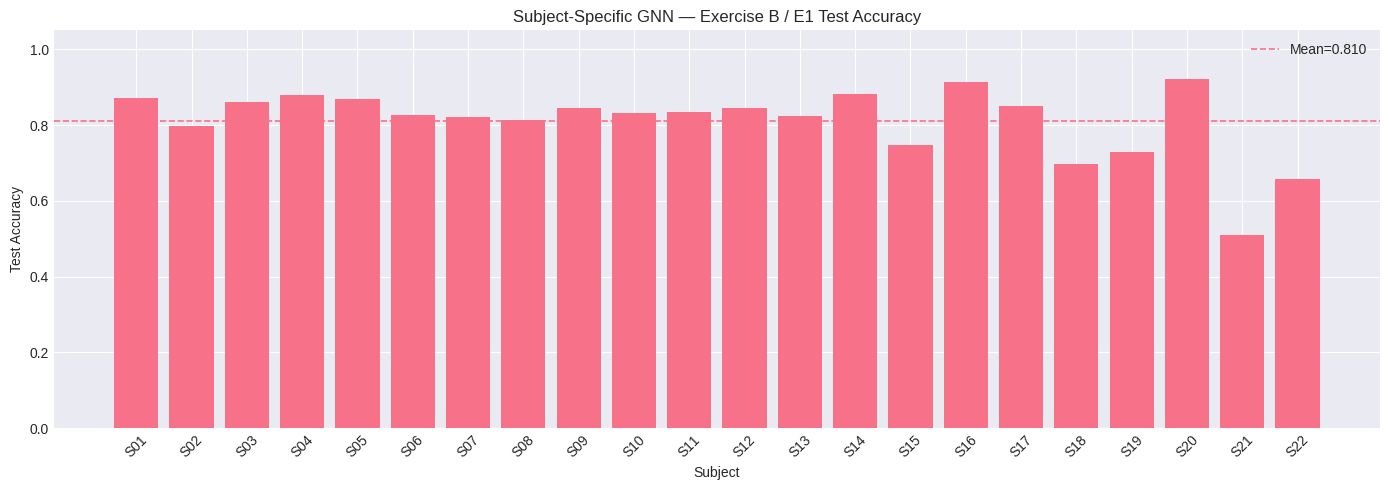

  Subject summary chart saved -> subject_specific_accuracy_summary.png

  FINAL SUBJECT-SPECIFIC WITHIN-SUBJECT SUMMARY
 subject  accuracy  balanced_accuracy     f1_w  roc_auc_w  best_epoch
       1  0.870841           0.861011 0.870728   0.995343          32
       2  0.798182           0.785629 0.790858   0.988912          43
       3  0.859574           0.852273 0.843843   0.994575          49
       4  0.878561           0.891213 0.874151   0.993923          77
       5  0.868613           0.883083 0.864511   0.995352          60
       6  0.827184           0.819820 0.822491   0.985718          49
       7  0.821853           0.818729 0.821329   0.992447          49
       8  0.812734           0.804357 0.809691   0.989139          45
       9  0.843818           0.860383 0.840459   0.990392          57
      10  0.832402           0.840984 0.835008   0.991963          39
      11  0.835200           0.830492 0.829273   0.992403          30
      12  0.844365           0.854971 0.

In [15]:
assert len(Config.SUBJECTS) == 22
assert set(Config.SUBJECTS) == set(range(1, 23))
assert set(Config.RUN_SUBJECTS).issubset(
    set(Config.SUBJECTS)
)
assert Config.TRAIN_REPS == 4
assert Config.VAL_REPS == 1
assert Config.TEST_REPS == 1
assert (
    Config.TRAIN_REPS
    + Config.VAL_REPS
    + Config.TEST_REPS
    == Config.REPS_PER_GESTURE
)
assert Config.WIN_MS == 400
assert Config.STEP_MS == 100
assert Config.USE_ACC is True
assert Config.EXERCISE_IDS == (1,)
assert Config.EXERCISE_NAME == 'exerciseB_E1_labels1_17'
assert Config.GESTURE_MIN == 1
assert Config.GESTURE_MAX == 17
assert Config.N_CLASSES == 17

print(
    'Running TRUE subject-specific within-subject GNN '
    'with DB7 Exercise B / E1 only (labels 1–17) and strict leakage-safe EMG + ACC.'
)
print(f'Subject models: {Config.RUN_SUBJECTS}')
print('Exercise B / E1 only; local labels 1–17.')
print(
    'For every subject/gesture: '
    '4 complete train repetitions + '
    '1 validation + 1 test repetition.'
)
print(
    'Safe order: split repetition -> filter EMG locally -> '
    'slice/resample ACC locally -> window -> modality-specific features -> '
    'training-only scaling/graph.'
)
print(
    'Architecture: 12 EMG graph nodes + separate ACC MLP branch -> fusion.'
)

(
    all_metrics,
    per_subject_results,
    aggregate_results,
    all_y_true,
    all_y_proba,
    repetition_assignments,
    repetition_provenance,
) = main_subject_specific_gnn()

print('\nExperiment complete.')
print(
    'Interpretation: subject-specific EMG+ACC GNN evaluated on '
    'unseen repetitions of the same participant.'
)

In [16]:
print('\n' + '=' * 70)
print('  WITHIN-SUBJECT GNN — EXERCISE B / E1 LABELS 1–17 — ONE MODEL PER SUBJECT')
print('=' * 70)

print(
    per_subject_results[
        [
            'subject',
            'accuracy',
            'balanced_accuracy',
            'precision_w',
            'recall_w',
            'f1_w',
            'roc_auc_w',
        ]
    ].to_string(index=False)
)

print('\nAcross subject-specific models:')
print(
    f'Mean Accuracy          : '
    f'{aggregate_results["mean_subject_accuracy"]:.4f} ± '
    f'{aggregate_results["std_subject_accuracy"]:.4f}'
)
print(
    f'Mean Balanced Accuracy : '
    f'{aggregate_results["mean_subject_balanced_accuracy"]:.4f} ± '
    f'{aggregate_results["std_subject_balanced_accuracy"]:.4f}'
)
print(
    f'Mean F1 (weighted)     : '
    f'{aggregate_results["mean_subject_f1_w"]:.4f} ± '
    f'{aggregate_results["std_subject_f1_w"]:.4f}'
)
print(
    f'Pooled Test Accuracy   : '
    f'{aggregate_results["pooled_test_accuracy"]:.4f}'
)

print(
    '\nReport this as: strict leakage-safe subject-specific within-subject EMG+ACC GNN evaluation on DB7 Exercise B / E1 only, labels 1–17. '
    'A separate GNN is trained for each DB7 subject using 4 training, '
    '1 validation, and 1 held-out test repetition per gesture.'
)


  WITHIN-SUBJECT GNN — EXERCISE B / E1 LABELS 1–17 — ONE MODEL PER SUBJECT
 subject  accuracy  balanced_accuracy  precision_w  recall_w     f1_w  roc_auc_w
       1  0.870841           0.861011     0.883581  0.870841 0.870728   0.995343
       2  0.798182           0.785629     0.802524  0.798182 0.790858   0.988912
       3  0.859574           0.852273     0.840119  0.859574 0.843843   0.994575
       4  0.878561           0.891213     0.893546  0.878561 0.874151   0.993923
       5  0.868613           0.883083     0.878146  0.868613 0.864511   0.995352
       6  0.827184           0.819820     0.837523  0.827184 0.822491   0.985718
       7  0.821853           0.818729     0.833742  0.821853 0.821329   0.992447
       8  0.812734           0.804357     0.830293  0.812734 0.809691   0.989139
       9  0.843818           0.860383     0.860219  0.843818 0.840459   0.990392
      10  0.832402           0.840984     0.850570  0.832402 0.835008   0.991963
      11  0.835200           0.83